**Data Preparation and EDA**

In [ ]:
# ============================================================
# NOTEBOOK 00: DATA PREPARATION AND EXPLORATORY DATA ANALYSIS
# Capstone: Predicting Debt Servicing Difficulties
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [ ]:
# ============================================================
# STEP 1: BUSINESS UNDERSTANDING
# ============================================================

print("""
Business Problem:
Philippine companies with weak debt servicing capacity may face future financial difficulty.
This project aims to develop an early warning model that predicts next-quarter debt servicing risk.

Machine Learning Task:
Supervised Binary Classification

Target:
1 = High Risk
0 = Low Risk

Target Definition:
Companies in the bottom 25% of the DSPR distribution are classified as High Risk.
""")


Business Problem:
Philippine companies with weak debt servicing capacity may face future financial difficulty.
This project aims to develop an early warning model that predicts next-quarter debt servicing risk.

Machine Learning Task:
Supervised Binary Classification

Target:
1 = High Risk
0 = Low Risk

Target Definition:
Companies in the bottom 25% of the DSPR distribution are classified as High Risk.



In [ ]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

file_path = "/content/Financial Dataset Final.xlsx"

df = pd.read_excel(file_path, sheet_name="F_Dataset")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (660, 38)


,COMPANY_CODE,YEAR,QUARTER,BS_CUR_ASSET_REPORT,BS_CUR_LIAB,BS_INVENTORIES,BS_TOT_ASSET,SHORT_AND_LONG_TERM_DEBT,TOTAL_EQUITY,BS_TOT_LIAB2,BS_LT_BORROW,BS_CASH_NEAR_CASH_ITEM,BS_ACCTS_REC_EXCL_NOTES_REC,NET_INCOME,SALES_REV_TURN,CF_NET_CASH_OPERATING_ACT_CB,CF_CASH_FROM_OPER,IS_INT_EXPENSE,BS_TOTAL_OPERATING_LEASE_LIABS,STDO,CUR_RATIO,QUICK_RATIO,ROA,NET_PROFIT_MARGIN,DEBT_TO_EQUITY,LONG_TERM_DEBT_RATIO,OPERATING_CASH_FLOW,OCF_GROWTH,CASH_EQUIVALENT,REVENUE_GROWTH,LOG_TOTAL_ASSET,GDP_GROWTH,BSP_RATE,INFLATION_RATE,US_PHP_RATE,DSR_INT,DSPR,TARGET
0,1,2020,4,207452.0070,151824.8840,55816.2100,824505.2580,318268.4310,343811.6160,480693.6420,251850.3630,53422.3490,67346.7160,7415.6940,23892.9180,8051.3080,6314.4920,2000.8110,0.0000,318268.4310,1.3664,0.9988,0.0090,0.3104,0.9257,0.3860,22501.6540,0.1427,88653.9560,0.1487,13.6225,-8.2000,2.1466,3.3000,48.0360,3.1560,0.0197,1
1,2,2020,4,100713.0000,27409.0000,29059.0000,221390.0000,103858.0000,89191.0000,132199.0000,99307.0000,7235.0000,44400.0000,2559.0000,10402.0000,7.0000,7.0000,0.0000,0.0000,103858.0000,3.6744,2.6143,0.0116,0.2460,1.1644,0.4691,-1372.8570,-0.9993,28077.1710,-0.4788,12.3077,-8.2000,2.1466,3.3000,48.0360,0.0000,0.0000,1
2,3,2020,4,212405.6650,217609.0210,78676.1930,959376.2000,380615.0240,411459.0570,547917.1430,266175.0740,32184.3400,69582.0200,10462.1990,30719.4720,17318.9630,15603.2020,3130.4240,0.0000,380615.0240,0.9761,0.6145,0.0109,0.3406,0.9250,0.3967,8488.2420,0.3715,65966.4110,0.0729,13.7740,-8.2000,2.1466,3.3000,48.0360,4.9844,0.0407,1
3,4,2020,4,220936.8320,191665.7360,76037.2100,1110879.7840,438435.9800,478312.8550,632566.9290,355201.7450,35410.2620,84324.4080,11660.5850,33278.7010,19872.2500,17762.8150,3279.6670,0.0000,438435.9800,1.1527,0.7560,0.0105,0.3504,0.9166,0.3947,11187.8429,0.1038,69697.6884,0.0154,13.9207,-8.2000,2.1466,3.3000,48.0360,5.4160,0.0402,1
4,5,2020,4,324271.1010,199729.3070,146743.5920,721494.3740,229706.7610,260179.3320,461315.0420,201376.2340,17037.3470,69341.5530,2359.1550,30390.4530,15493.5030,15493.5030,0.0000,0.0000,229706.7610,1.6236,0.8888,0.0033,0.0776,0.8829,0.3184,15493.5030,-0.6536,17037.3470,-0.3169,13.4891,-8.2000,2.1466,3.3000,48.0360,0.0000,0.0000,1


In [ ]:
# ============================================================
# STEP 3.1: DATASET OVERVIEW
# ============================================================

print("Rows and columns:", df.shape)

display(df.head())
display(df.tail())

df.info()

Rows and columns: (660, 38)


,COMPANY_CODE,YEAR,QUARTER,BS_CUR_ASSET_REPORT,BS_CUR_LIAB,BS_INVENTORIES,BS_TOT_ASSET,SHORT_AND_LONG_TERM_DEBT,TOTAL_EQUITY,BS_TOT_LIAB2,BS_LT_BORROW,BS_CASH_NEAR_CASH_ITEM,BS_ACCTS_REC_EXCL_NOTES_REC,NET_INCOME,SALES_REV_TURN,CF_NET_CASH_OPERATING_ACT_CB,CF_CASH_FROM_OPER,IS_INT_EXPENSE,BS_TOTAL_OPERATING_LEASE_LIABS,STDO,CUR_RATIO,QUICK_RATIO,ROA,NET_PROFIT_MARGIN,DEBT_TO_EQUITY,LONG_TERM_DEBT_RATIO,OPERATING_CASH_FLOW,OCF_GROWTH,CASH_EQUIVALENT,REVENUE_GROWTH,LOG_TOTAL_ASSET,GDP_GROWTH,BSP_RATE,INFLATION_RATE,US_PHP_RATE,DSR_INT,DSPR,TARGET
0,1,2020,4,207452.0070,151824.8840,55816.2100,824505.2580,318268.4310,343811.6160,480693.6420,251850.3630,53422.3490,67346.7160,7415.6940,23892.9180,8051.3080,6314.4920,2000.8110,0.0000,318268.4310,1.3664,0.9988,0.0090,0.3104,0.9257,0.3860,22501.6540,0.1427,88653.9560,0.1487,13.6225,-8.2000,2.1466,3.3000,48.0360,3.1560,0.0197,1
1,2,2020,4,100713.0000,27409.0000,29059.0000,221390.0000,103858.0000,89191.0000,132199.0000,99307.0000,7235.0000,44400.0000,2559.0000,10402.0000,7.0000,7.0000,0.0000,0.0000,103858.0000,3.6744,2.6143,0.0116,0.2460,1.1644,0.4691,-1372.8570,-0.9993,28077.1710,-0.4788,12.3077,-8.2000,2.1466,3.3000,48.0360,0.0000,0.0000,1
2,3,2020,4,212405.6650,217609.0210,78676.1930,959376.2000,380615.0240,411459.0570,547917.1430,266175.0740,32184.3400,69582.0200,10462.1990,30719.4720,17318.9630,15603.2020,3130.4240,0.0000,380615.0240,0.9761,0.6145,0.0109,0.3406,0.9250,0.3967,8488.2420,0.3715,65966.4110,0.0729,13.7740,-8.2000,2.1466,3.3000,48.0360,4.9844,0.0407,1
3,4,2020,4,220936.8320,191665.7360,76037.2100,1110879.7840,438435.9800,478312.8550,632566.9290,355201.7450,35410.2620,84324.4080,11660.5850,33278.7010,19872.2500,17762.8150,3279.6670,0.0000,438435.9800,1.1527,0.7560,0.0105,0.3504,0.9166,0.3947,11187.8429,0.1038,69697.6884,0.0154,13.9207,-8.2000,2.1466,3.3000,48.0360,5.4160,0.0402,1
4,5,2020,4,324271.1010,199729.3070,146743.5920,721494.3740,229706.7610,260179.3320,461315.0420,201376.2340,17037.3470,69341.5530,2359.1550,30390.4530,15493.5030,15493.5030,0.0000,0.0000,229706.7610,1.6236,0.8888,0.0033,0.0776,0.8829,0.3184,15493.5030,-0.6536,17037.3470,-0.3169,13.4891,-8.2000,2.1466,3.3000,48.0360,0.0000,0.0000,1


,COMPANY_CODE,YEAR,QUARTER,BS_CUR_ASSET_REPORT,BS_CUR_LIAB,BS_INVENTORIES,BS_TOT_ASSET,SHORT_AND_LONG_TERM_DEBT,TOTAL_EQUITY,BS_TOT_LIAB2,BS_LT_BORROW,BS_CASH_NEAR_CASH_ITEM,BS_ACCTS_REC_EXCL_NOTES_REC,NET_INCOME,SALES_REV_TURN,CF_NET_CASH_OPERATING_ACT_CB,CF_CASH_FROM_OPER,IS_INT_EXPENSE,BS_TOTAL_OPERATING_LEASE_LIABS,STDO,CUR_RATIO,QUICK_RATIO,ROA,NET_PROFIT_MARGIN,DEBT_TO_EQUITY,LONG_TERM_DEBT_RATIO,OPERATING_CASH_FLOW,OCF_GROWTH,CASH_EQUIVALENT,REVENUE_GROWTH,LOG_TOTAL_ASSET,GDP_GROWTH,BSP_RATE,INFLATION_RATE,US_PHP_RATE,DSR_INT,DSPR,TARGET
655,26,2026,1,14656.4786,4805.9064,6379.7652,22397.3686,3400.0000,16564.7368,5832.6318,1000.0000,1775.0171,4579.4749,784.6881,6370.8514,113.1334,92.1104,21.1390,0.0000,3400.0000,3.0497,1.7222,0.0350,0.1232,0.2053,0.1518,10550.0000,-0.9648,98179.0000,-0.0774,10.0167,2.8000,4.2500,3.2000,60.4650,4.3574,0.0269,1
656,27,2026,1,14283.8167,7936.9985,5363.0385,25160.6617,4262.9695,17176.5205,7984.1411,47.1426,2646.3228,3574.9122,572.6288,5744.7532,932.6816,886.4441,46.2374,0.0000,4262.9695,1.7996,1.1239,0.0228,0.0997,0.2482,0.1694,19872.2500,-0.1384,35410.2620,0.2764,10.1330,2.8000,4.2500,3.2000,60.4650,19.1716,0.2057,1
657,28,2026,1,28395.6235,22656.0073,11371.8052,48369.3992,21912.0902,21789.6232,26579.7760,3776.9550,2837.9281,8052.6775,532.5999,11192.4096,-2829.3439,-3171.5537,318.1966,0.0000,21912.0902,1.2533,0.7514,0.0110,0.0476,1.0056,0.4530,22751.0000,13.2577,14534.0000,0.0651,10.7866,2.8000,4.2500,3.2000,60.4650,-9.9673,-0.1427,1
658,29,2026,1,23802.7560,14771.1460,8135.7916,39104.3468,14083.6955,19021.1532,20083.1936,5247.3644,3780.0121,6414.2970,850.6366,12328.5275,-247.7216,-373.4712,125.7496,0.0000,14083.6955,1.6114,1.0606,0.0218,0.0690,0.7404,0.3602,88.1800,-2.3278,655.2590,0.2334,10.5740,2.8000,4.2500,3.2000,60.4650,-2.9700,-0.0263,1
659,30,2026,1,17912.8020,11288.3494,6634.0790,29254.0187,7993.4614,17798.8934,11455.1253,80.7950,3043.7578,3595.6779,671.3762,6900.8268,305.5530,263.0494,42.5036,0.0000,7993.4614,1.5868,0.9991,0.0229,0.0973,0.4491,0.2732,5869.0000,-2.2021,5071.0000,-0.0147,10.2838,2.8000,4.2500,3.2000,60.4650,6.1889,0.0327,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   COMPANY_CODE                    660 non-null    int64  
 1   YEAR                            660 non-null    int64  
 2   QUARTER                         660 non-null    int64  
 3   BS_CUR_ASSET_REPORT             660 non-null    float64
 4   BS_CUR_LIAB                     660 non-null    float64
 5   BS_INVENTORIES                  660 non-null    float64
 6   BS_TOT_ASSET                    660 non-null    float64
 7   SHORT_AND_LONG_TERM_DEBT        660 non-null    float64
 8   TOTAL_EQUITY                    660 non-null    float64
 9   BS_TOT_LIAB2                    660 non-null    float64
 10  BS_LT_BORROW                    660 non-null    float64
 11  BS_CASH_NEAR_CASH_ITEM          660 non-null    float64
 12  BS_ACCTS_REC_EXCL_NOTES_REC     660 

In [ ]:
# ============================================================
# STEP 3.2: MISSING VALUES
# ============================================================

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
}).sort_values(by="Missing Percent", ascending=False)

display(missing_df)

,Missing Count,Missing Percent
COMPANY_CODE,0,0.0000
YEAR,0,0.0000
QUARTER,0,0.0000
BS_CUR_ASSET_REPORT,0,0.0000
BS_CUR_LIAB,0,0.0000
BS_INVENTORIES,0,0.0000
BS_TOT_ASSET,0,0.0000
SHORT_AND_LONG_TERM_DEBT,0,0.0000
TOTAL_EQUITY,0,0.0000
BS_TOT_LIAB2,0,0.0000


In [ ]:
# ============================================================
# STEP 3.3: DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# ============================================================
# STEP 3.4: SUMMARY STATISTICS
# ============================================================

summary_stats = df.describe().T

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
COMPANY_CODE,660.0000,15.5000,8.6620,1.0000,8.0000,15.5000,23.0000,30.0000
YEAR,660.0000,2023.0000,1.6249,2020.0000,2022.0000,2023.0000,2024.0000,2026.0000
QUARTER,660.0000,2.5000,1.1589,1.0000,1.0000,2.5000,4.0000,4.0000
BS_CUR_ASSET_REPORT,660.0000,45868.5879,60674.0550,0.0000,5124.9465,24334.6839,69545.9352,449204.9230
BS_CUR_LIAB,660.0000,49290.0569,66380.0654,0.0000,4052.6171,18078.8371,67823.8628,282827.6890
BS_INVENTORIES,660.0000,9120.8295,24400.3298,0.0000,312.9185,3429.5000,7563.9001,239293.1860
BS_TOT_ASSET,660.0000,181060.3547,221409.9179,0.0000,23079.6393,72434.2513,297277.9688,1110879.7840
SHORT_AND_LONG_TERM_DEBT,660.0000,73093.5562,99826.0439,0.0000,4201.5775,21481.0516,102039.5805,438435.9800
TOTAL_EQUITY,660.0000,58579.5556,74585.2367,-117733.0666,4400.9532,23399.4711,94650.6144,478312.8550
BS_TOT_LIAB2,660.0000,122481.2650,160022.7776,0.0000,8494.0030,33257.9606,206781.8670,632566.9290


In [ ]:
# ============================================================
# STEP 3.5: PREPARE QUARTER COLUMN
# ============================================================

df["QUARTER_NUM"] = df["QUARTER"].astype(int)

df = df.sort_values(
    by=["COMPANY_CODE", "YEAR", "QUARTER_NUM"]
).reset_index(drop=True)

df[["COMPANY_CODE", "YEAR", "QUARTER", "QUARTER_NUM"]].head()

,COMPANY_CODE,YEAR,QUARTER,QUARTER_NUM
0,1,2020,4,4
1,1,2021,1,1
2,1,2021,2,2
3,1,2021,3,3
4,1,2021,4,4


In [ ]:
# ============================================================
# STEP 4: DATA CLEANING
# ============================================================

# Replace infinite values with missing values
df = df.replace([np.inf, -np.inf], np.nan)

# Confirm missing values after cleaning
missing_after_cleaning = df.isnull().sum().sort_values(ascending=False)

display(missing_after_cleaning)

,0
COMPANY_CODE,0
YEAR,0
QUARTER,0
BS_CUR_ASSET_REPORT,0
BS_CUR_LIAB,0
BS_INVENTORIES,0
BS_TOT_ASSET,0
SHORT_AND_LONG_TERM_DEBT,0
TOTAL_EQUITY,0
BS_TOT_LIAB2,0


In [ ]:
# ============================================================
# STEP 5: FEATURE ENGINEERING CHECK
# ============================================================

# Check if engineered variables already exist
engineered_vars = [
    "CUR_RATIO",
    "QUICK_RATIO",
    "ROA",
    "NET_PROFIT_MARGIN",
    "DEBT_TO_EQUITY",
    "LONG_TERM_DEBT_RATIO",
    "OPERATING_CASH_FLOW",
    "OCF_GROWTH",
    "REVENUE_GROWTH",
    "LOG_TOTAL_ASSET",
    "DSPR"
]

existing_engineered_vars = [col for col in engineered_vars if col in df.columns]

print("Existing engineered variables:")
print(existing_engineered_vars)

Existing engineered variables:
['CUR_RATIO', 'QUICK_RATIO', 'ROA', 'NET_PROFIT_MARGIN', 'DEBT_TO_EQUITY', 'LONG_TERM_DEBT_RATIO', 'OPERATING_CASH_FLOW', 'OCF_GROWTH', 'REVENUE_GROWTH', 'LOG_TOTAL_ASSET', 'DSPR']


In [ ]:
# ============================================================
# STEP 6: CREATE TARGET VARIABLE
# Redefining the target variable using the Bottom 25% DSPR = High Risk
# The class distribution became more balanced
# ============================================================

df["DSPR"] = df["DSPR"].replace([np.inf, -np.inf], np.nan)

dspr_threshold = df["DSPR"].quantile(0.25)

print("DSPR 25th percentile threshold:", dspr_threshold)

df["TARGET_NEW"] = np.where(
    df["DSPR"] <= dspr_threshold,
    1,
    0
)

print("\nTarget distribution:")
print(df["TARGET_NEW"].value_counts())

print("\nTarget distribution percentage:")
print(df["TARGET_NEW"].value_counts(normalize=True))

DSPR 25th percentile threshold: 0.0

Target distribution:
TARGET_NEW
0    393
1    267
Name: count, dtype: int64

Target distribution percentage:
TARGET_NEW
0   0.5955
1   0.4045
Name: proportion, dtype: float64


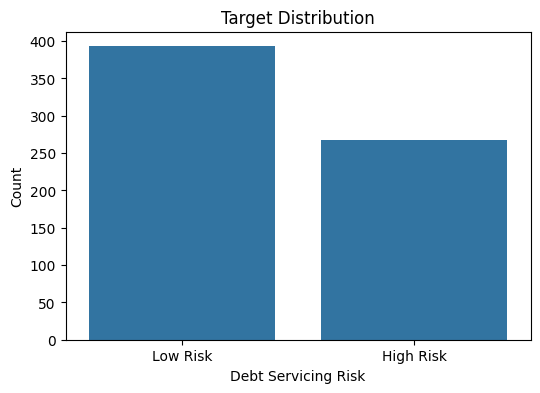

In [ ]:
# ============================================================
# STEP 6.1: TARGET DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    x="TARGET_NEW",
    data=df
)

plt.title("Target Distribution")
plt.xlabel("Debt Servicing Risk")
plt.ylabel("Count")
plt.xticks([0, 1], ["Low Risk", "High Risk"])

plt.show()

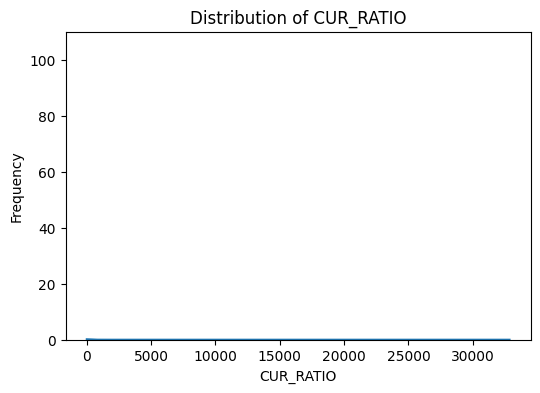

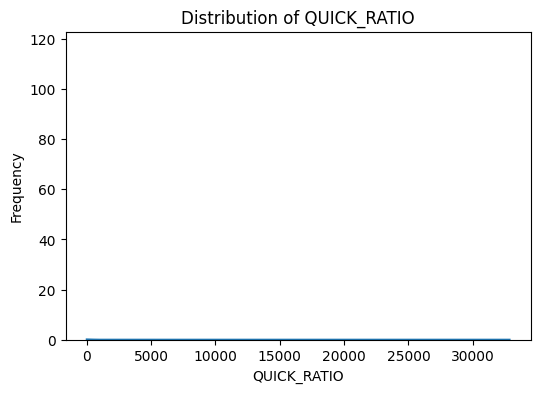

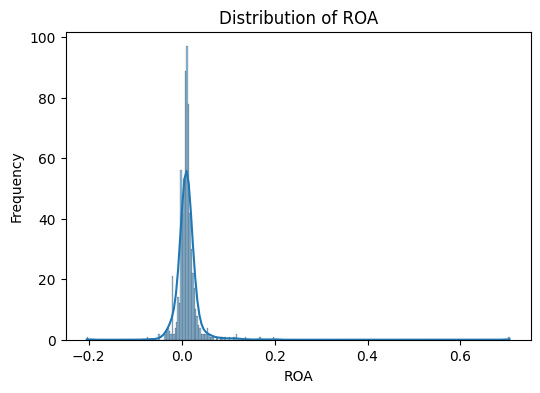

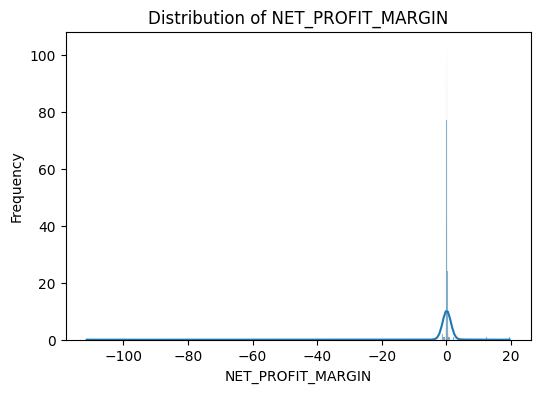

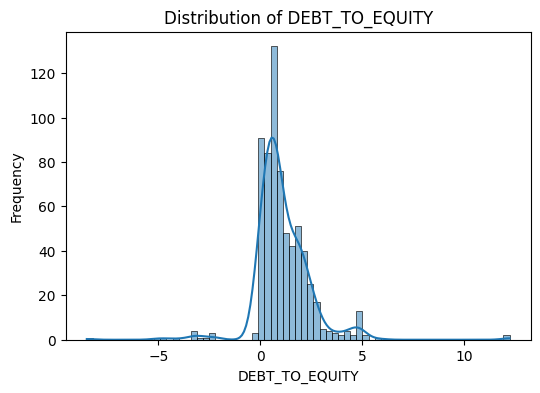

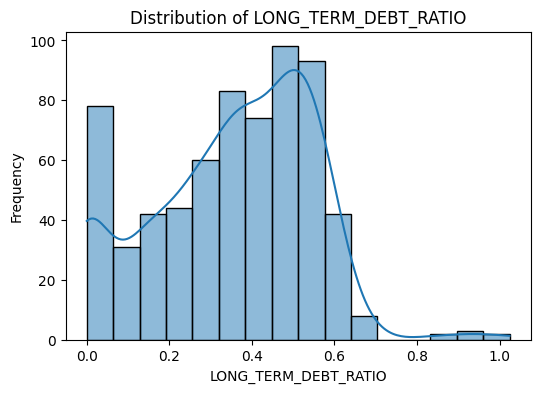

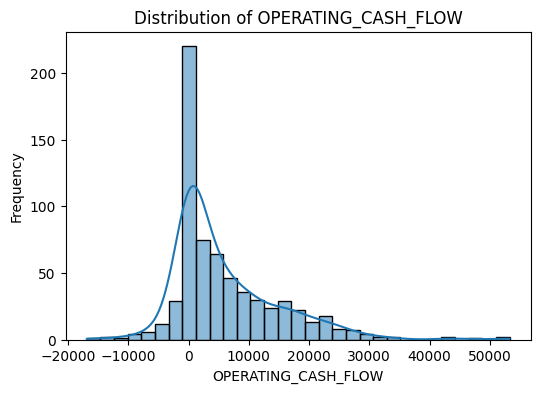

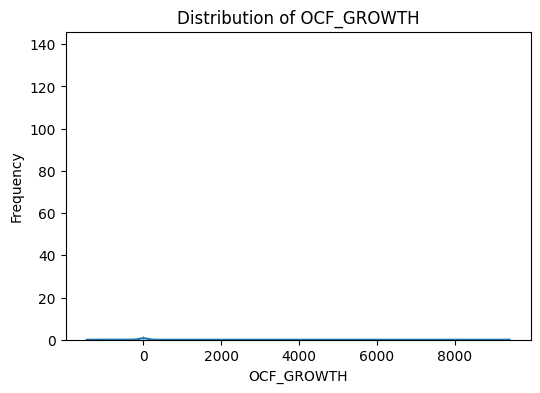

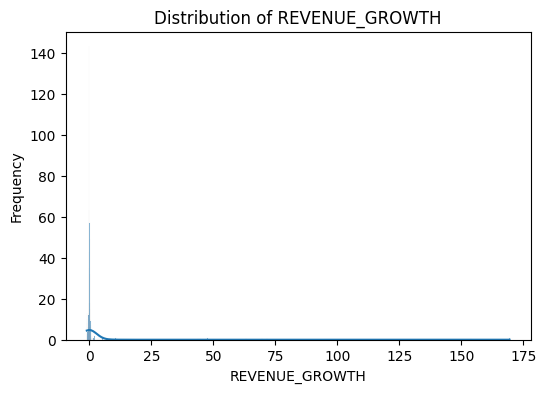

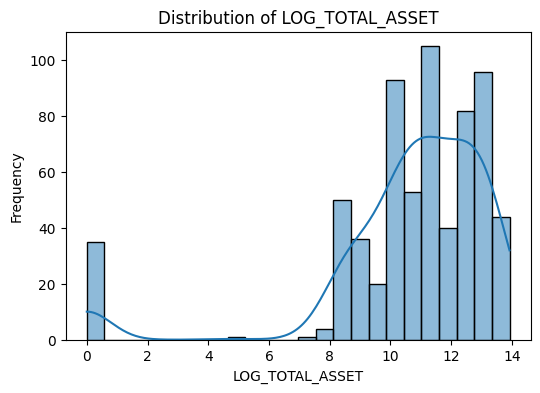

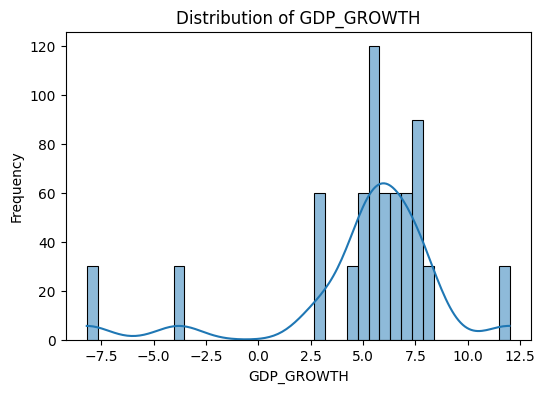

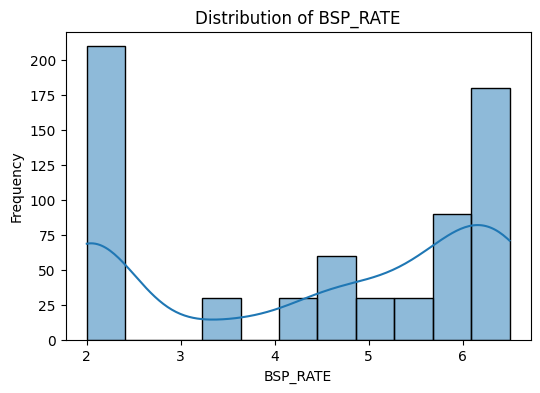

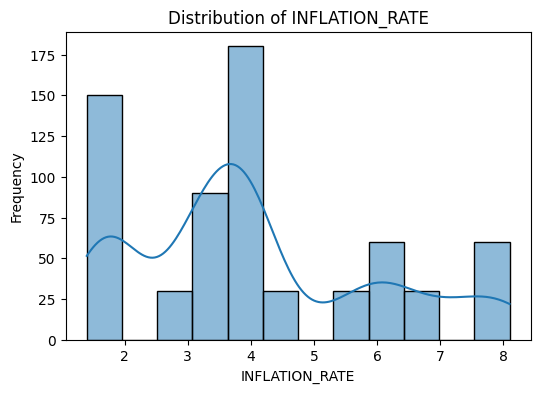

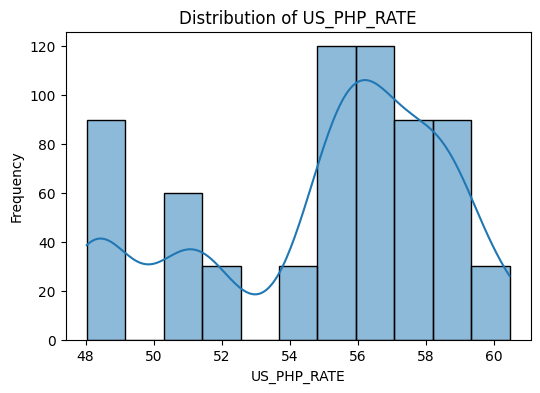

In [ ]:
# ============================================================
# STEP 7: CONTINUOUS VARIABLE DISTRIBUTIONS
# ============================================================

continuous_vars = [
    "CUR_RATIO",
    "QUICK_RATIO",
    "ROA",
    "NET_PROFIT_MARGIN",
    "DEBT_TO_EQUITY",
    "LONG_TERM_DEBT_RATIO",
    "OPERATING_CASH_FLOW",
    "OCF_GROWTH",
    "REVENUE_GROWTH",
    "LOG_TOTAL_ASSET",
    "GDP_GROWTH",
    "BSP_RATE",
    "INFLATION_RATE",
    "US_PHP_RATE"
]

continuous_vars = [col for col in continuous_vars if col in df.columns]

for col in continuous_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

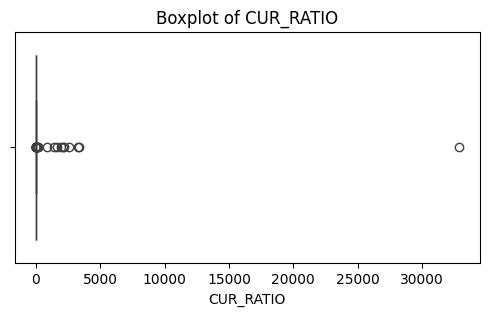

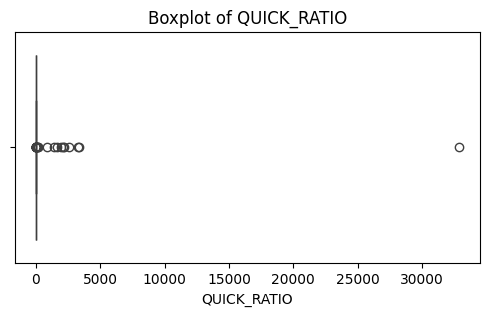

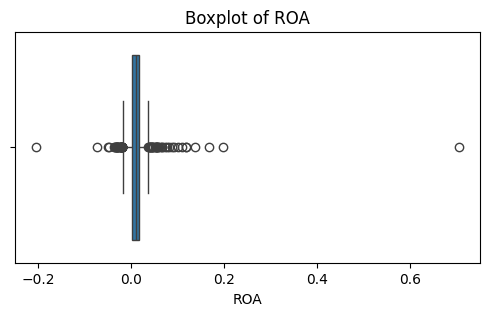

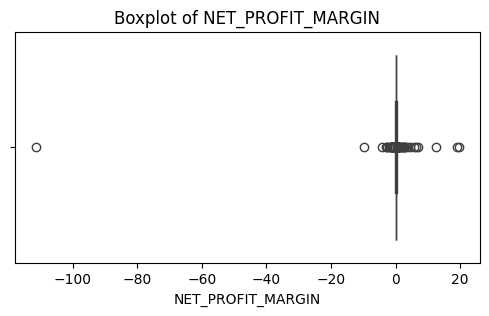

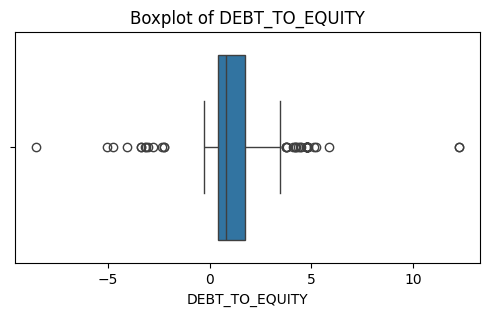

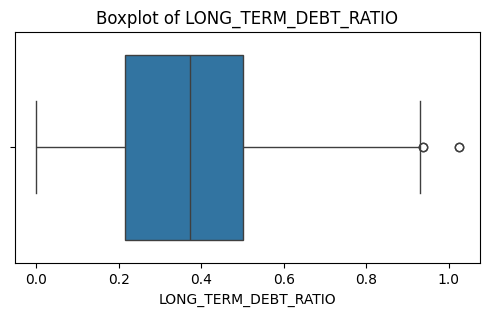

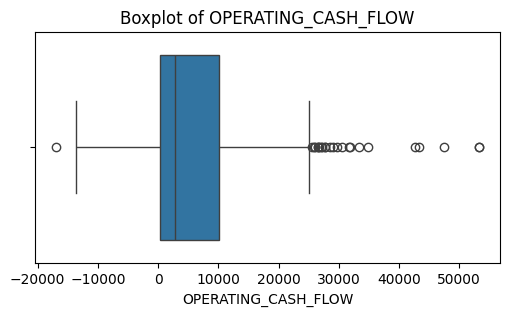

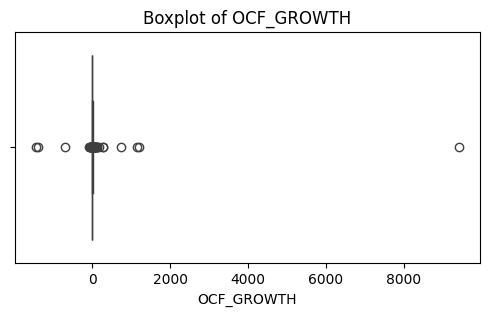

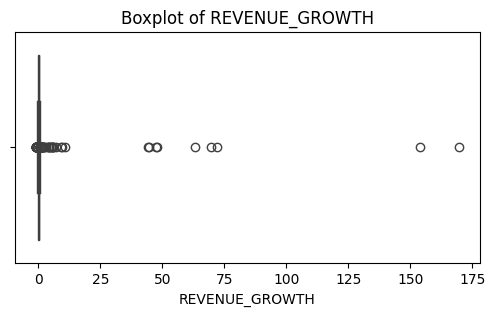

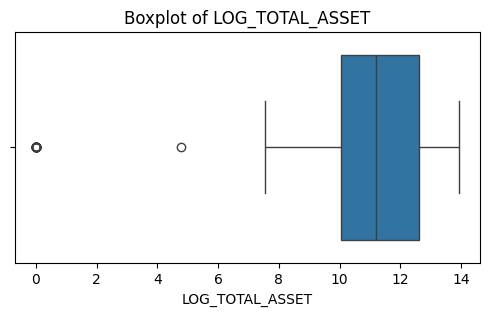

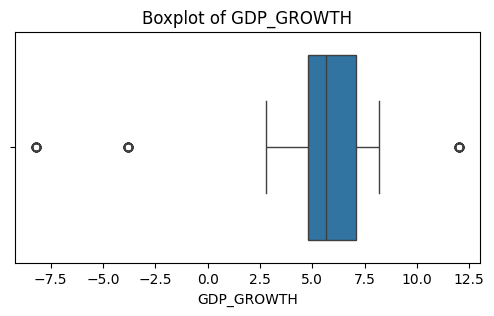

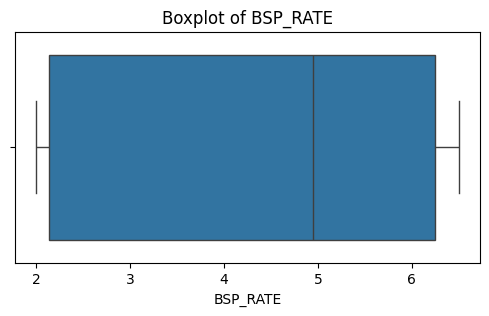

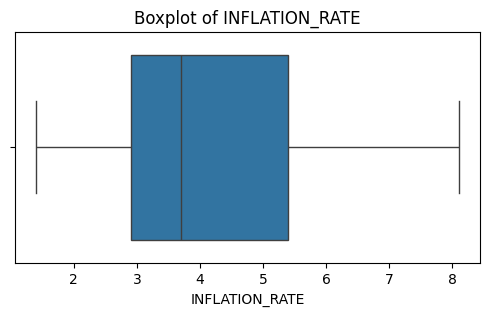

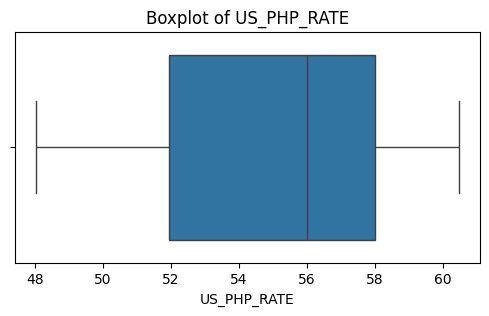

In [ ]:
# ============================================================
# STEP 8: OUTLIER DETECTION USING BOXPLOTS
# ============================================================

for col in continuous_vars:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
# ============================================================
# STEP 8.1: IQR OUTLIER SUMMARY
# ============================================================

outlier_summary = []

for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Variable": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percent": len(outliers) / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.sort_values(by="Outlier Percent", ascending=False))

,Variable,Lower Bound,Upper Bound,Outlier Count,Outlier Percent
8,REVENUE_GROWTH,-0.4207,0.5271,118,17.8788
7,OCF_GROWTH,-2.8322,2.3718,117,17.7273
10,GDP_GROWTH,1.3500,10.5500,90,13.6364
2,ROA,-0.0179,0.0370,74,11.2121
3,NET_PROFIT_MARGIN,-0.3147,0.5720,71,10.7576
0,CUR_RATIO,-0.7627,3.2699,46,6.9697
4,DEBT_TO_EQUITY,-1.5578,3.7256,42,6.3636
1,QUICK_RATIO,-0.3989,2.3365,38,5.7576
9,LOG_TOTAL_ASSET,6.2131,16.4360,36,5.4545
6,OPERATING_CASH_FLOW,-14630.4879,25020.3840,24,3.6364


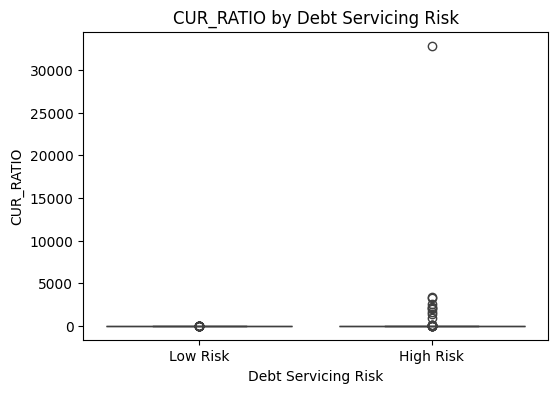

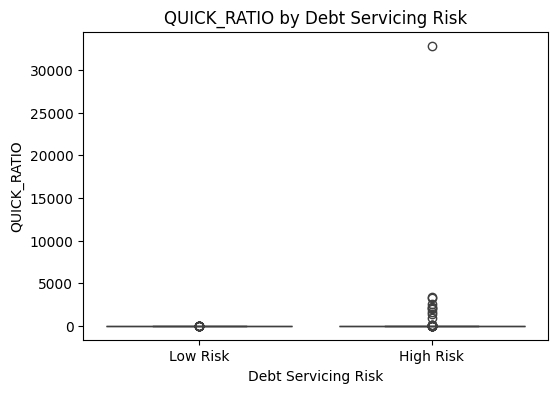

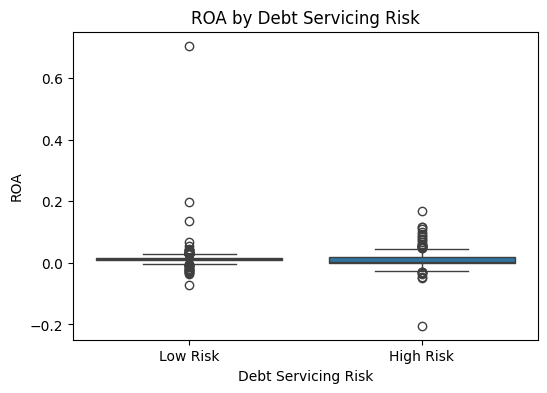

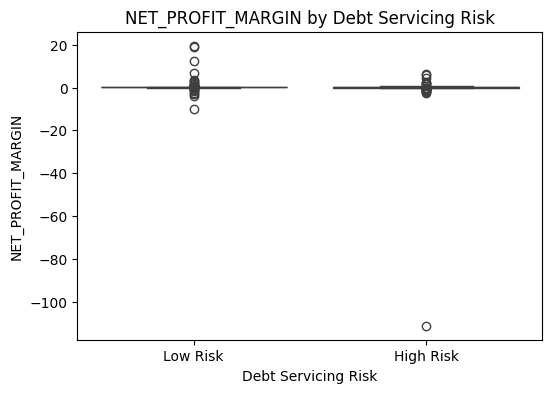

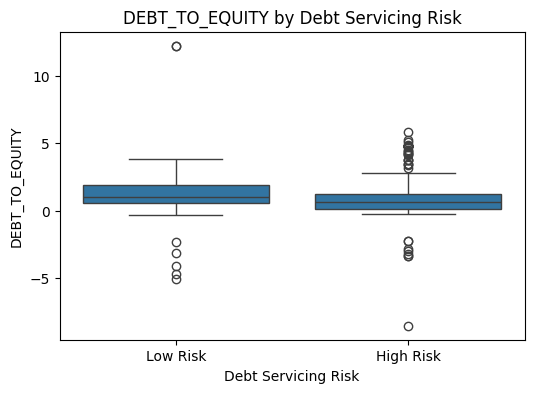

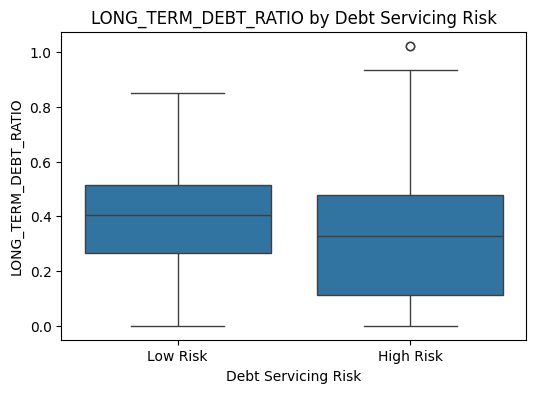

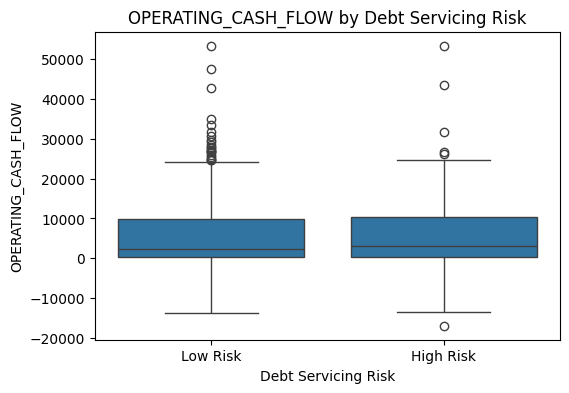

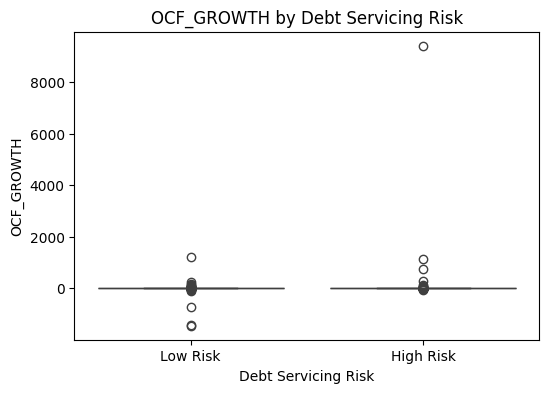

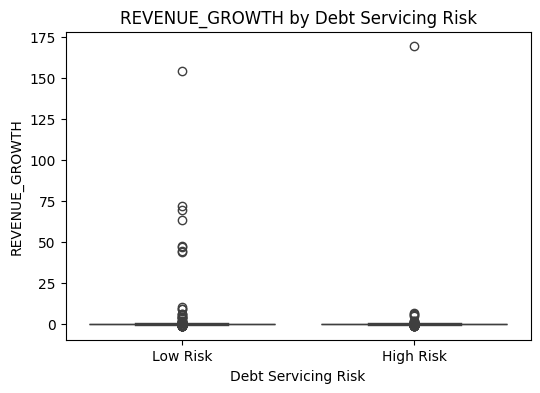

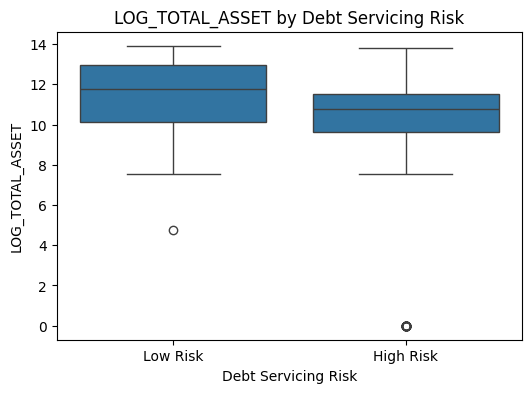

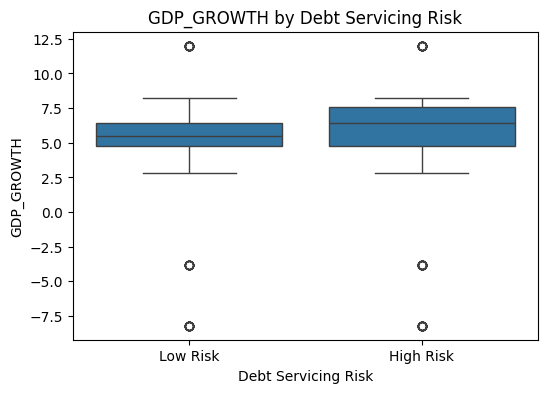

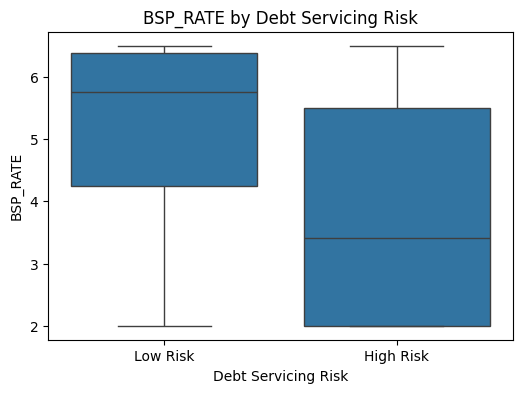

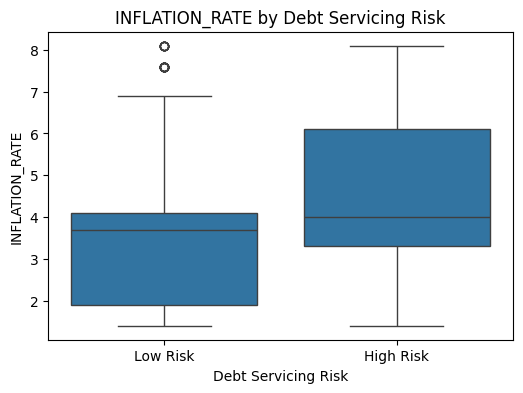

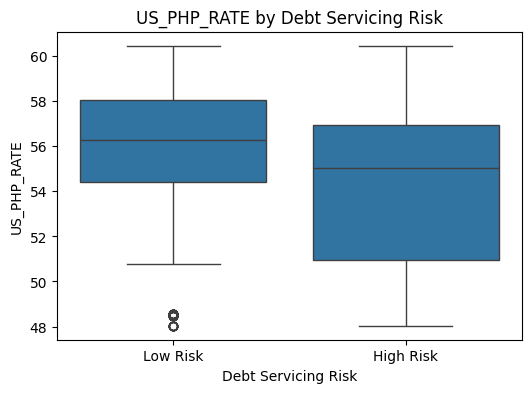

In [ ]:
# ============================================================
# STEP 9: RELATIONSHIP BETWEEN VARIABLES AND TARGET
# ============================================================

for col in continuous_vars:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        x="TARGET_NEW",
        y=col,
        data=df
    )

    plt.title(f"{col} by Debt Servicing Risk")
    plt.xlabel("Debt Servicing Risk")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Low Risk", "High Risk"])

    plt.show()

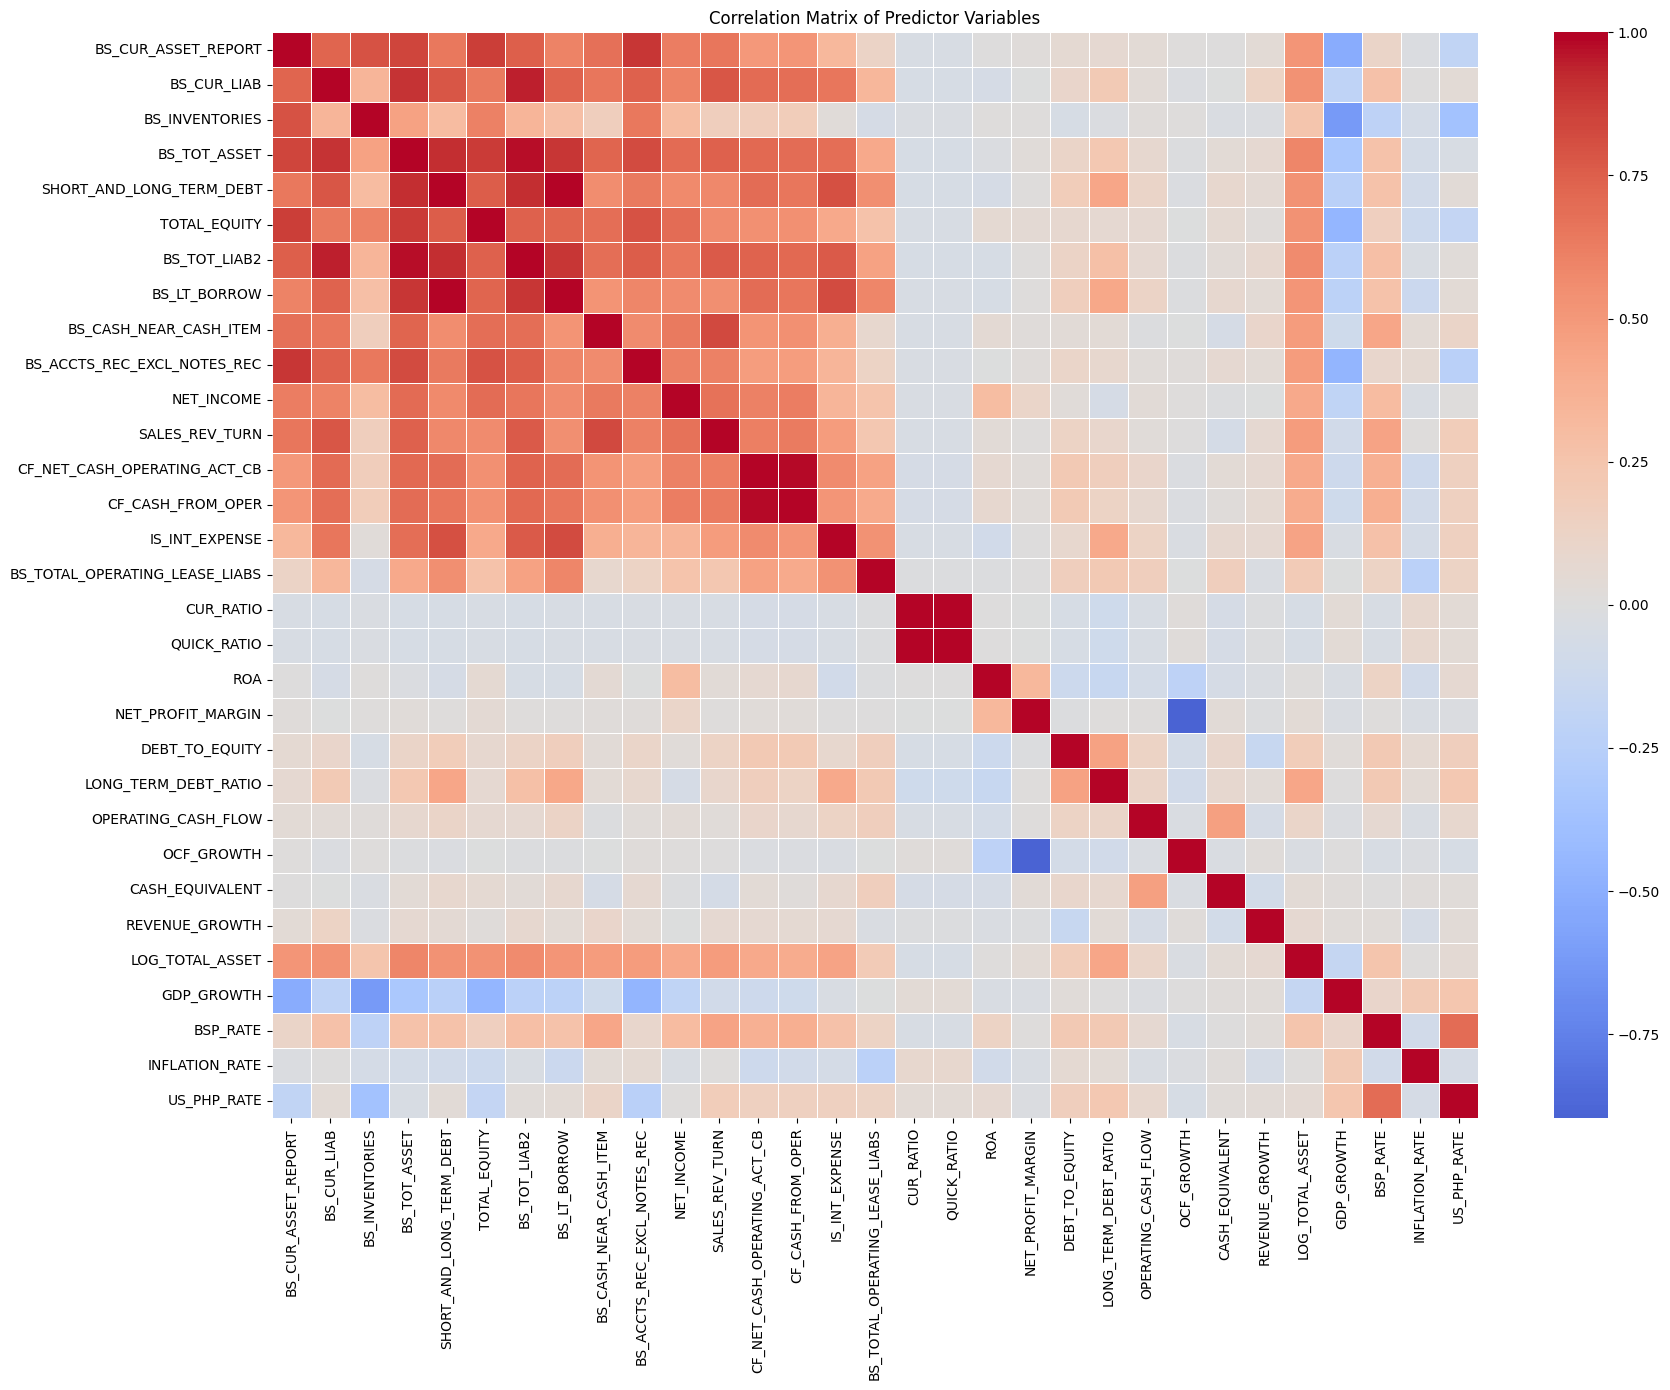

In [ ]:
# ============================================================
# STEP 10: CORRELATION ANALYSIS
# ============================================================

exclude_cols = [
    "COMPANY_CODE",
    "COMPANY_NAME",
    "YEAR",
    "QUARTER",
    "QUARTER_NUM",
    "TARGET",
    "TARGET_NEW",
    "TARGET_NEXT_QTR",
    "DSPR",
    "DSR_INT",
    "STDO"
]

feature_df = df.drop(columns=exclude_cols, errors="ignore")

numeric_feature_df = feature_df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_feature_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Predictor Variables")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 11: FEATURE SELECTION USING CORRELATION FILTER
# ============================================================

threshold = 0.90

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for column in upper.columns:
    for row in upper.index:
        value = upper.loc[row, column]

        if pd.notnull(value) and abs(value) >= threshold:
            high_corr_pairs.append([
                row,
                column,
                round(value, 3)
            ])

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Variable 1", "Variable 2", "Correlation"]
)

print("Highly correlated variable pairs:")
display(high_corr_df)

to_drop_corr = [
    column for column in upper.columns
    if any(abs(upper[column]) >= threshold)
]

print("Variables recommended for removal:")
print(to_drop_corr)

Highly correlated variable pairs:


,Variable 1,Variable 2,Correlation
0,BS_TOT_ASSET,SHORT_AND_LONG_TERM_DEBT,0.9160
1,BS_CUR_LIAB,BS_TOT_LIAB2,0.9430
2,BS_TOT_ASSET,BS_TOT_LIAB2,0.9750
3,SHORT_AND_LONG_TERM_DEBT,BS_TOT_LIAB2,0.9160
4,SHORT_AND_LONG_TERM_DEBT,BS_LT_BORROW,0.9890
5,CF_NET_CASH_OPERATING_ACT_CB,CF_CASH_FROM_OPER,0.9810
6,CUR_RATIO,QUICK_RATIO,1.0000


Variables recommended for removal:
['SHORT_AND_LONG_TERM_DEBT', 'BS_TOT_LIAB2', 'BS_LT_BORROW', 'CF_CASH_FROM_OPER', 'QUICK_RATIO']


In [ ]:
# ============================================================
# STEP 11.1: APPLY FEATURE SELECTION
# ============================================================

selected_feature_df = feature_df.drop(
    columns=to_drop_corr,
    errors="ignore"
)

selected_features = selected_feature_df.columns.tolist()

print("Original number of features:", feature_df.shape[1])
print("Selected number of features:", len(selected_features))

print("\nSelected features:")
print(selected_features)

pd.DataFrame({
    "Selected_Features": selected_features
}).to_csv(
    "Selected_Features_Correlation_Filter.csv",
    index=False
)

Original number of features: 31
Selected number of features: 26

Selected features:
['BS_CUR_ASSET_REPORT', 'BS_CUR_LIAB', 'BS_INVENTORIES', 'BS_TOT_ASSET', 'TOTAL_EQUITY', 'BS_CASH_NEAR_CASH_ITEM', 'BS_ACCTS_REC_EXCL_NOTES_REC', 'NET_INCOME', 'SALES_REV_TURN', 'CF_NET_CASH_OPERATING_ACT_CB', 'IS_INT_EXPENSE', 'BS_TOTAL_OPERATING_LEASE_LIABS', 'CUR_RATIO', 'ROA', 'NET_PROFIT_MARGIN', 'DEBT_TO_EQUITY', 'LONG_TERM_DEBT_RATIO', 'OPERATING_CASH_FLOW', 'OCF_GROWTH', 'CASH_EQUIVALENT', 'REVENUE_GROWTH', 'LOG_TOTAL_ASSET', 'GDP_GROWTH', 'BSP_RATE', 'INFLATION_RATE', 'US_PHP_RATE']


In [ ]:
# ============================================================
# STEP 12: CREATE NEXT-QUARTER TARGET
# ============================================================

df["TARGET_NEXT_QTR"] = (
    df.groupby("COMPANY_CODE")["TARGET_NEW"]
      .shift(-1)
)

print("TARGET_NEXT_QTR distribution:")
print(df["TARGET_NEXT_QTR"].value_counts(dropna=False))

TARGET_NEXT_QTR distribution:
TARGET_NEXT_QTR
0.0000    380
1.0000    250
NaN        30
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 13: TIME-BASED TRAIN/TEST SPLIT
# Data: 2020 Q4 to 2026 Q1
# Train: 2020 Q4 to 2024 Q4
# Test: 2025 Q1 to 2025 Q4
# Forecast: 2026 Q1 to predict 2026 Q2
# ============================================================

model_df = df.dropna(subset=["TARGET_NEXT_QTR"]).copy()

model_df["TARGET_NEXT_QTR"] = model_df["TARGET_NEXT_QTR"].astype(int)

train_df = model_df[
    model_df["YEAR"] <= 2024
].copy()

test_df = model_df[
    (model_df["YEAR"] == 2025) &
    (model_df["QUARTER_NUM"].isin([1, 2, 3, 4]))
].copy()

predict_2026q2 = df[
    (df["YEAR"] == 2026) &
    (df["QUARTER_NUM"] == 1)
].copy()

predict_2026q2["FEATURE_YEAR"] = predict_2026q2["YEAR"]
predict_2026q2["FEATURE_QUARTER"] = predict_2026q2["QUARTER"]
predict_2026q2["PREDICTION_YEAR"] = 2026
predict_2026q2["PREDICTION_QUARTER"] = 2

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Forecast shape:", predict_2026q2.shape)

Train shape: (510, 41)
Test shape: (120, 41)
Forecast shape: (30, 45)


In [ ]:
# ============================================================
# STEP 14: SAVE FINAL DATASETS
# ============================================================

train_df.to_csv("Train_Data_2020Q4_to_2024Q4.csv", index=False)
test_df.to_csv("Test_Data_2025Q1_to_2025Q4.csv", index=False)
predict_2026q2.to_csv("Forecast_Input_2026Q1_for_2026Q2.csv", index=False)

print("Final datasets saved successfully.")

Final datasets saved successfully.



EDA Summary:
The exploratory data analysis examined data structure, missing values, duplicate records,
summary statistics, distributions, outliers, relationships with the target variable,
and correlations among predictors.

Since this project is a supervised binary classification task, clustering tendency analysis
was not performed because it is applicable only to unsupervised learning problems.

Correlation analysis was used as a filter-based feature selection method to identify
highly correlated variables and reduce redundancy before model development.


Logistic Regression CV ROC-AUC Scores: [0.73951049 0.66497748 0.65657143 0.70363409 0.79673423]
Mean CV ROC-AUC: 0.7122855430013325
Std CV ROC-AUC: 0.05155529554867657
Best Parameters: {'classifier__solver': 'liblinear', 'classifier__C': 1}
Best CV ROC-AUC: 0.7121768678926573
            Dataset  ROC_AUC
0          Training   0.8107
1  Cross Validation   0.7123
2           Testing   0.6032

Generalization Gap : 0.2076
Possible overfitting detected.


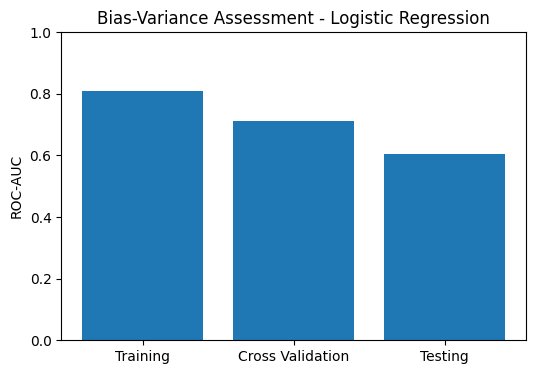

                 Model                                        Best_Params  \
0  Logistic Regression  {'classifier__solver': 'liblinear', 'classifie...   

   CV_ROC_AUC_Mean  CV_ROC_AUC_Std  Accuracy  Precision  Recall  F1_Score  \
0           0.7123          0.0516    0.6000     0.3000  0.2500    0.2727   

   ROC_AUC  
0   0.6032  
[[63 21]
 [27  9]]
              precision    recall  f1-score   support

    Low Risk       0.70      0.75      0.72        84
   High Risk       0.30      0.25      0.27        36

    accuracy                           0.60       120
   macro avg       0.50      0.50      0.50       120
weighted avg       0.58      0.60      0.59       120

                                Feature  Coefficient  Absolute_Coefficient
11  num__BS_TOTAL_OPERATING_LEASE_LIABS      -1.4151                1.4151
18                      num__OCF_GROWTH       1.1488                1.1488
8                   num__SALES_REV_TURN      -1.1131                1.1131
23                

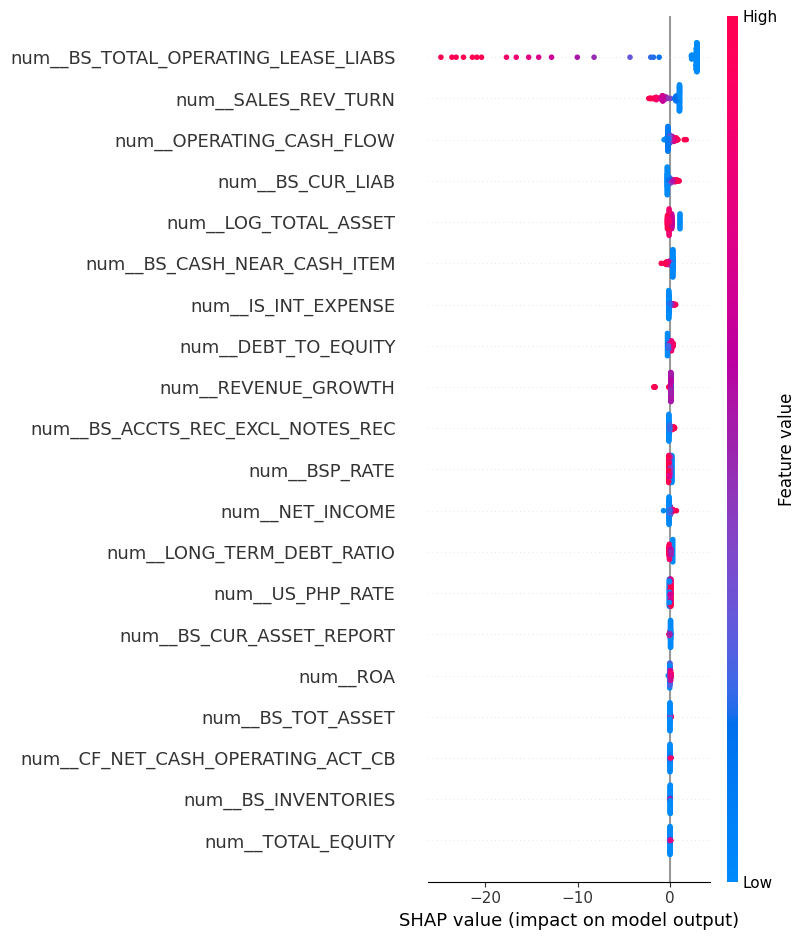

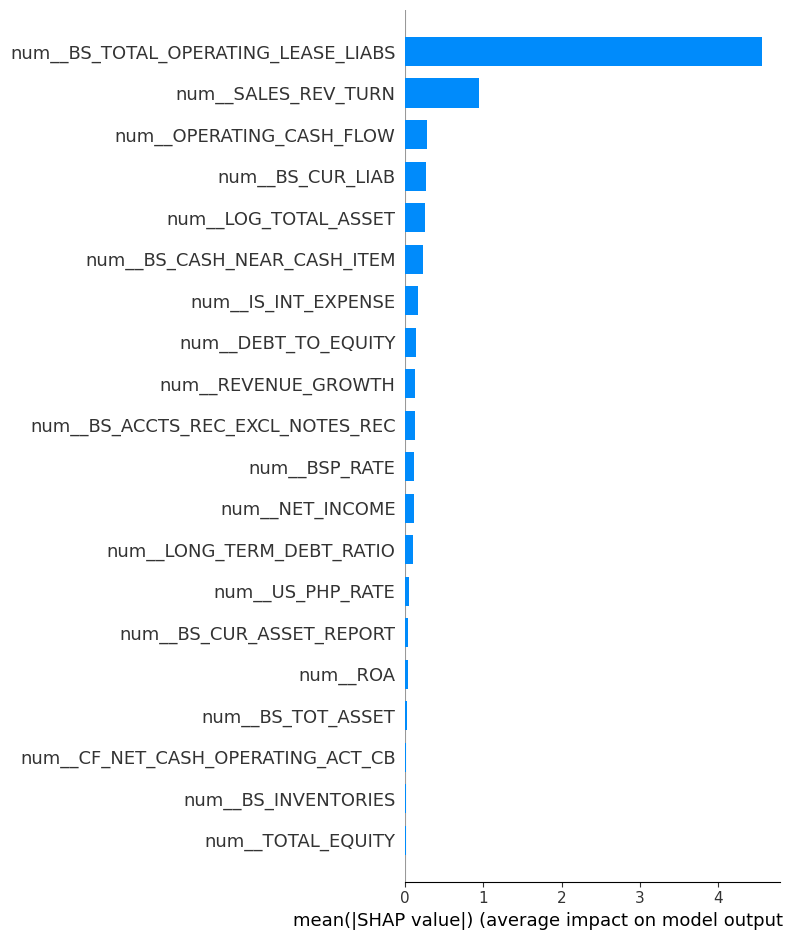

                                Feature  Mean_Absolute_SHAP
11  num__BS_TOTAL_OPERATING_LEASE_LIABS              4.5609
8                   num__SALES_REV_TURN              0.9476
17             num__OPERATING_CASH_FLOW              0.2804
1                      num__BS_CUR_LIAB              0.2711
21                 num__LOG_TOTAL_ASSET              0.2483
5           num__BS_CASH_NEAR_CASH_ITEM              0.2324
10                  num__IS_INT_EXPENSE              0.1642
15                  num__DEBT_TO_EQUITY              0.1417
20                  num__REVENUE_GROWTH              0.1289
6      num__BS_ACCTS_REC_EXCL_NOTES_REC              0.1187
23                        num__BSP_RATE              0.1117
7                       num__NET_INCOME              0.1059
16            num__LONG_TERM_DEBT_RATIO              0.0939
25                     num__US_PHP_RATE              0.0546
0              num__BS_CUR_ASSET_REPORT              0.0380
13                             num__ROA 

In [ ]:
# ============================================================
# LOGISTIC REGRESSION USING FINAL DATASETS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# STEP 1: Load final datasets
# ------------------------------------------------------------

train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

# ------------------------------------------------------------
# STEP 2: Define X and y
# ------------------------------------------------------------

target_col = "TARGET_NEXT_QTR"

X_train = train_df[selected_features]
y_train = train_df[target_col]

X_test = test_df[selected_features]
y_test = test_df[target_col]

X_forecast = forecast_df[selected_features]

# ------------------------------------------------------------
# STEP 3: Identify feature types
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------------------------------------------
# STEP 4: Preprocessing
# Logistic Regression requires scaling
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# ------------------------------------------------------------
# STEP 5: Build and train model
# ------------------------------------------------------------

logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

# ------------------------------------------------------------
# STEP 5.1: Time-series cross-validation
# ------------------------------------------------------------

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    logreg_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC Scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())
print("Std CV ROC-AUC:", cv_scores.std())

cv_df = pd.DataFrame({
    "Fold": np.arange(1, len(cv_scores)+1),
    "ROC_AUC": cv_scores
})

cv_df.loc[len(cv_df)] = [
    "Mean",
    cv_scores.mean()
]

cv_df.to_csv(
    "CrossValidation_LogisticRegression.csv",
    index=False
)

# ------------------------------------------------------------
# STEP 6: Hyperparameter tuning
# ------------------------------------------------------------

param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"]
}

search = RandomizedSearchCV(
    estimator=logreg_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_logreg_model = search.best_estimator_

print("Best Parameters:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# ============================================================
# STEP 7: OVERFITTING / UNDERFITTING ASSESSMENT
# Logistic Regression
# ============================================================

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# Training Performance
train_prob = best_logreg_model.predict_proba(X_train)[:,1]
train_auc = roc_auc_score(y_train, train_prob)

# Testing Performance
test_prob = best_logreg_model.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, test_prob)

# Cross Validation Performance
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

bias_variance_df = pd.DataFrame({
    "Dataset":[
        "Training",
        "Cross Validation",
        "Testing"
    ],
    "ROC_AUC":[
        train_auc,
        cv_mean,
        test_auc
    ]
})

print(bias_variance_df)

gap = train_auc - test_auc

print(f"\nGeneralization Gap : {gap:.4f}")

if gap < 0.05:
    interpretation = "Excellent generalization. Minimal overfitting."

elif gap < 0.10:
    interpretation = "Slight overfitting but still acceptable."

else:
    interpretation = "Possible overfitting detected."

print(interpretation)

bias_variance_df.to_csv(
    "LogisticRegression_BiasVariance.csv",
    index=False
)

plt.figure(figsize=(6,4))

plt.bar(
    bias_variance_df["Dataset"],
    bias_variance_df["ROC_AUC"]
)

plt.ylim(0,1)

plt.ylabel("ROC-AUC")

plt.title("Bias-Variance Assessment - Logistic Regression")

plt.show()

# ------------------------------------------------------------
# STEP 8: Evaluate model
# ------------------------------------------------------------

y_pred = best_logreg_model.predict(X_test)
y_prob = best_logreg_model.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [cv_scores.mean()],
    "CV_ROC_AUC_Std": [cv_scores.std()],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred, zero_division=0)],
    "Recall": [recall_score(y_test, y_pred, zero_division=0)],
    "F1_Score": [f1_score(y_test, y_pred, zero_division=0)],
    "ROC_AUC": [roc_auc_score(y_test, y_prob)]
})

print(metrics_df)
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))
print(classification_report(y_test, y_pred, labels=[0, 1],
                            target_names=["Low Risk", "High Risk"],
                            zero_division=0))

metrics_df.to_csv("LogisticRegression_Metrics_Tuned_Final.csv", index=False)

# ------------------------------------------------------------
# STEP 9: Coefficient importance
# ------------------------------------------------------------

feature_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

coef_df.to_csv("LogisticRegression_Coefficients_Final.csv", index=False)
print(coef_df.head(20))

# ============================================================
# STEP 10: SHAP EXPLAINABILITY - LOGISTIC REGRESSION
# ============================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt

# Transform test data using fitted preprocessor
X_test_transformed = logreg_model.named_steps["preprocessor"].transform(X_test)

feature_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Use LinearExplainer for Logistic Regression
explainer = shap.LinearExplainer(
    logreg_model.named_steps["classifier"],
    X_test_shap
)

shap_values = explainer.shap_values(X_test_shap)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_shap,
    show=True
)

# SHAP bar plot
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=True
)

# Save mean absolute SHAP values
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": abs(shap_values).mean(axis=0)
}).sort_values(by="Mean_Absolute_SHAP", ascending=False)

shap_importance.to_csv(
    "LogisticRegression_SHAP_Importance_Final.csv",
    index=False
)

print(shap_importance.head(20))

# ------------------------------------------------------------
# STEP 11: Predict 2026 Q2 using 2026 Q1 features
# ------------------------------------------------------------

forecast_df["LR_Probability_High_Risk"] = logreg_model.predict_proba(X_forecast)[:, 1]
forecast_df["LR_Prediction"] = logreg_model.predict(X_forecast)
forecast_df["LR_Risk_Level"] = forecast_df["LR_Prediction"].map({
    0: "Low Risk",
    1: "High Risk"
})

output_cols = [
    "COMPANY_CODE",
    "FEATURE_YEAR",
    "FEATURE_QUARTER",
    "PREDICTION_YEAR",
    "PREDICTION_QUARTER",
    "LR_Probability_High_Risk",
    "LR_Prediction",
    "LR_Risk_Level"
]

forecast_df[output_cols].to_csv("LogisticRegression_2026Q2_Predictions_Final.csv", index=False)
print(forecast_df[output_cols])

Random Forest CV ROC-AUC Scores: [0.85198135 0.75337838 0.81942857 0.85526316 0.85698198]
Mean CV ROC-AUC: 0.8274066883330041
Std CV ROC-AUC: 0.03949287532802689
Best Parameters: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'log2', 'classifier__max_depth': None}
Best CV ROC-AUC: 0.8336802279749648
            Dataset  ROC_AUC
0          Training   0.9744
1  Cross Validation   0.8274
2           Testing   0.8343

Generalization Gap : 0.1401
Possible overfitting detected.


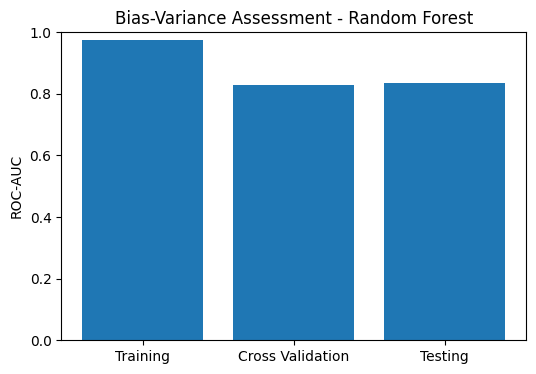

           Model                                        Best_Params  \
0  Random Forest  {'classifier__n_estimators': 500, 'classifier_...   

   CV_ROC_AUC_Mean  CV_ROC_AUC_Std  Accuracy  Precision  Recall  F1_Score  \
0           0.8274          0.0395    0.8583     0.7714  0.7500    0.7606   

   ROC_AUC  
0   0.8343  
[[76  8]
 [ 9 27]]
              precision    recall  f1-score   support

    Low Risk       0.89      0.90      0.90        84
   High Risk       0.77      0.75      0.76        36

    accuracy                           0.86       120
   macro avg       0.83      0.83      0.83       120
weighted avg       0.86      0.86      0.86       120

                              Feature  Importance
10                num__IS_INT_EXPENSE      0.0829
8                 num__SALES_REV_TURN      0.0757
23                      num__BSP_RATE      0.0649
22                    num__GDP_GROWTH      0.0576
13                           num__ROA      0.0533
5         num__BS_CASH_NEAR_CA

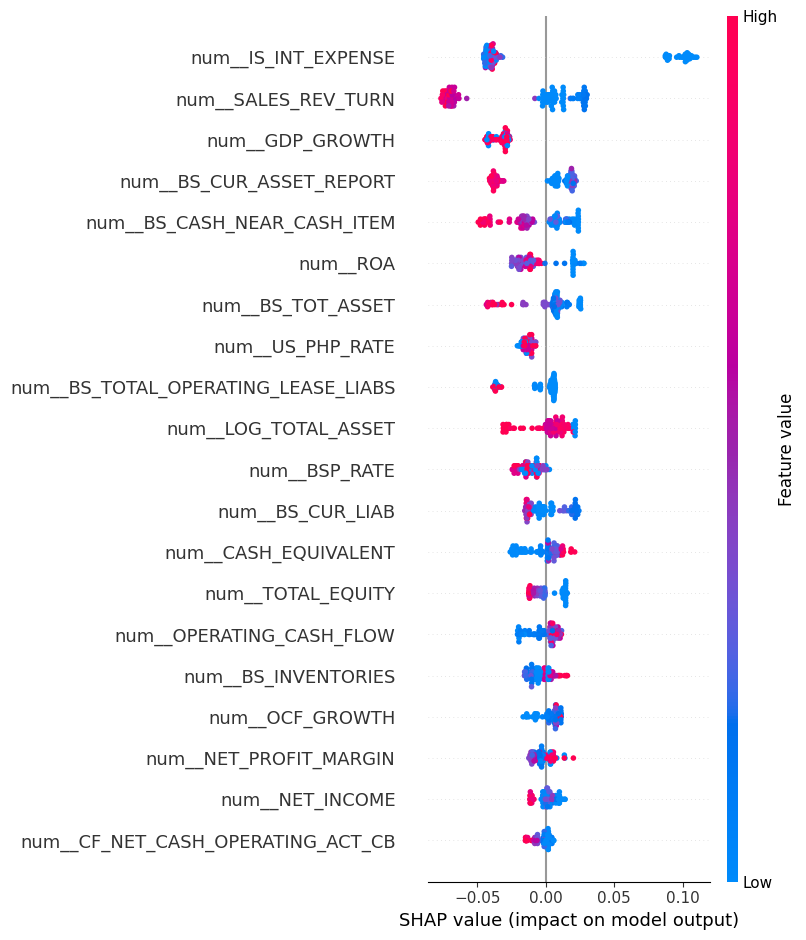

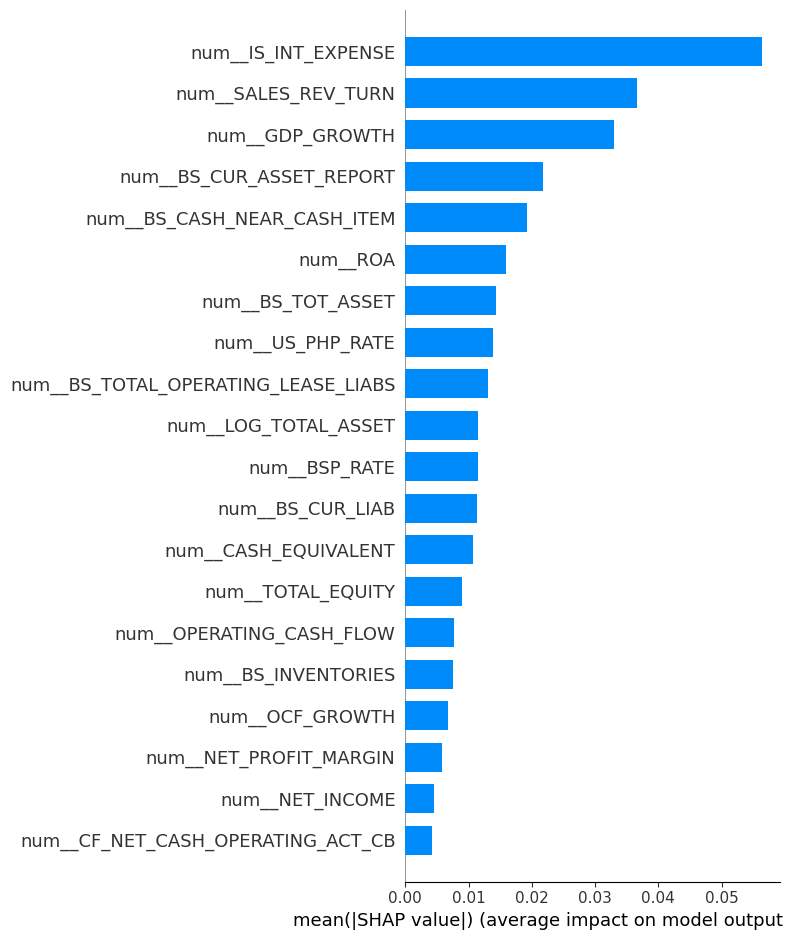

                                Feature  Mean_Absolute_SHAP
10                  num__IS_INT_EXPENSE              0.0564
8                   num__SALES_REV_TURN              0.0366
22                      num__GDP_GROWTH              0.0331
0              num__BS_CUR_ASSET_REPORT              0.0218
5           num__BS_CASH_NEAR_CASH_ITEM              0.0193
13                             num__ROA              0.0159
3                     num__BS_TOT_ASSET              0.0143
25                     num__US_PHP_RATE              0.0139
11  num__BS_TOTAL_OPERATING_LEASE_LIABS              0.0130
21                 num__LOG_TOTAL_ASSET              0.0115
23                        num__BSP_RATE              0.0115
1                      num__BS_CUR_LIAB              0.0114
19                 num__CASH_EQUIVALENT              0.0107
4                     num__TOTAL_EQUITY              0.0090
17             num__OPERATING_CASH_FLOW              0.0077
2                   num__BS_INVENTORIES 

In [ ]:
# ============================================================
# RANDOM FOREST USING FINAL DATASETS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

# STEP 1: Load final datasets

train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

target_col = "TARGET_NEXT_QTR"

X_train = train_df[selected_features]
y_train = train_df[target_col]

X_test = test_df[selected_features]
y_test = test_df[target_col]

X_forecast = forecast_df[selected_features]


# STEP 2: Identify feature types

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


# STEP 3: Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)


# STEP 4: Base model

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)


# STEP 5: Time-series cross-validation

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="roc_auc"
)

print("Random Forest CV ROC-AUC Scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())
print("Std CV ROC-AUC:", cv_scores.std())

cv_df = pd.DataFrame({
    "Fold": np.arange(1, len(cv_scores)+1),
    "ROC_AUC": cv_scores
})

cv_df.loc[len(cv_df)] = [
    "Mean",
    cv_scores.mean()
]

cv_df.to_csv(
    "CrossValidation_RandomForest.csv",
    index=False
)

# STEP 6: Hyperparameter tuning

param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, 8, 10, None],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf": [2, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_rf_model = search.best_estimator_

print("Best Parameters:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)


# ============================================================
# STEP 7: OVERFITTING / UNDERFITTING ASSESSMENT
# Random Forest
# ============================================================

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

train_prob = best_rf_model.predict_proba(X_train)[:,1]
train_auc = roc_auc_score(y_train, train_prob)

test_prob = best_rf_model.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, test_prob)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

bias_variance_df = pd.DataFrame({
    "Dataset":[
        "Training",
        "Cross Validation",
        "Testing"
    ],
    "ROC_AUC":[
        train_auc,
        cv_mean,
        test_auc
    ]
})

print(bias_variance_df)

gap = train_auc - test_auc

print(f"\nGeneralization Gap : {gap:.4f}")

if gap < 0.05:
    interpretation = "Excellent generalization. Minimal overfitting."

elif gap < 0.10:
    interpretation = "Slight overfitting but acceptable."

else:
    interpretation = "Possible overfitting detected."

print(interpretation)

bias_variance_df.to_csv(
    "RandomForest_BiasVariance.csv",
    index=False
)

plt.figure(figsize=(6,4))

plt.bar(
    bias_variance_df["Dataset"],
    bias_variance_df["ROC_AUC"]
)

plt.ylim(0,1)

plt.ylabel("ROC-AUC")

plt.title("Bias-Variance Assessment - Random Forest")

plt.show()


# STEP 8: Final test evaluation

y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [cv_scores.mean()],
    "CV_ROC_AUC_Std": [cv_scores.std()],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred, zero_division=0)],
    "Recall": [recall_score(y_test, y_pred, zero_division=0)],
    "F1_Score": [f1_score(y_test, y_pred, zero_division=0)],
    "ROC_AUC": [roc_auc_score(y_test, y_prob)]
})

print(metrics_df)
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))
print(classification_report(y_test, y_pred, labels=[0, 1],
                            target_names=["Low Risk", "High Risk"],
                            zero_division=0))

metrics_df.to_csv("RandomForest_Metrics_Tuned_Final.csv", index=False)


# STEP 9: Feature importance

feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
importance = best_rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

importance_df.to_csv("RandomForest_FeatureImportance_Tuned_Final.csv", index=False)
print(importance_df.head(20))

# ============================================================
# STEP 10: SHAP EXPLAINABILITY - RANDOM FOREST
# ============================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt

# Transform test data using fitted preprocessor
X_test_transformed = rf_model.named_steps["preprocessor"].transform(X_test)

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Get trained classifier
rf_classifier = rf_model.named_steps["classifier"]

# SHAP Tree Explainer
explainer = shap.TreeExplainer(rf_classifier)

shap_values = explainer.shap_values(X_test_shap)

# For binary classification, use class 1 = High Risk
if isinstance(shap_values, list):
    shap_values_high_risk = shap_values[1]
else:
    shap_values_high_risk = shap_values[:, :, 1]

# SHAP summary plot
shap.summary_plot(
    shap_values_high_risk,
    X_test_shap,
    show=True
)

# SHAP bar plot
shap.summary_plot(
    shap_values_high_risk,
    X_test_shap,
    plot_type="bar",
    show=True
)

# Save mean absolute SHAP values
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": abs(shap_values_high_risk).mean(axis=0)
}).sort_values(by="Mean_Absolute_SHAP", ascending=False)

shap_importance.to_csv(
    "RandomForest_SHAP_Importance_Final.csv",
    index=False
)

print(shap_importance.head(20))

# STEP 11: Predict 2026 Q2

forecast_df["RF_Probability_High_Risk"] = best_rf_model.predict_proba(X_forecast)[:, 1]
forecast_df["RF_Prediction"] = best_rf_model.predict(X_forecast)
forecast_df["RF_Risk_Level"] = forecast_df["RF_Prediction"].map({0: "Low Risk", 1: "High Risk"})

output_cols = [
    "COMPANY_CODE", "FEATURE_YEAR", "FEATURE_QUARTER",
    "PREDICTION_YEAR", "PREDICTION_QUARTER",
    "RF_Probability_High_Risk", "RF_Prediction", "RF_Risk_Level"
]

forecast_df[output_cols].to_csv("RandomForest_2026Q2_Predictions_Tuned_Final.csv", index=False)
print(forecast_df[output_cols])

XGBoost CV ROC-AUC Scores: [0.78991841 0.73704955 0.82628571 0.84711779 0.84290541]
Mean CV ROC-AUC: 0.8086553757290599
Std CV ROC-AUC: 0.04108946110713427
Best Parameters: {'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 3, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.9}
Best CV ROC-AUC: 0.8270433024538286
            Dataset  ROC_AUC
0          Training   0.9634
1  Cross Validation   0.8087
2           Testing   0.8037

Generalization Gap : 0.1597
Possible overfitting detected.


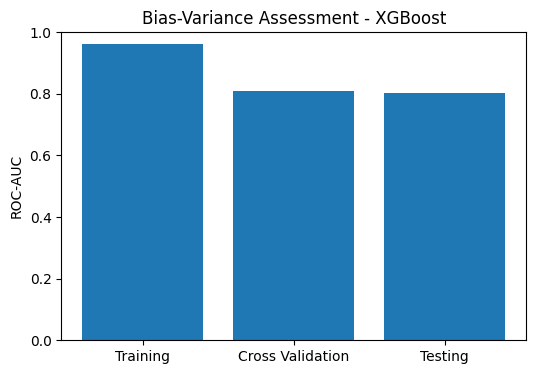

     Model                                        Best_Params  \
0  XGBoost  {'classifier__subsample': 1.0, 'classifier__n_...   

   CV_ROC_AUC_Mean  CV_ROC_AUC_Std  Accuracy  Precision  Recall  F1_Score  \
0           0.8087          0.0411    0.7833     0.6389  0.6389    0.6389   

   ROC_AUC  
0   0.8037  
[[71 13]
 [13 23]]
              precision    recall  f1-score   support

    Low Risk       0.85      0.85      0.85        84
   High Risk       0.64      0.64      0.64        36

    accuracy                           0.78       120
   macro avg       0.74      0.74      0.74       120
weighted avg       0.78      0.78      0.78       120

                                Feature  Importance
10                  num__IS_INT_EXPENSE      0.1544
8                   num__SALES_REV_TURN      0.0916
23                        num__BSP_RATE      0.0762
22                      num__GDP_GROWTH      0.0656
19                 num__CASH_EQUIVALENT      0.0501
11  num__BS_TOTAL_OPERATING_LE

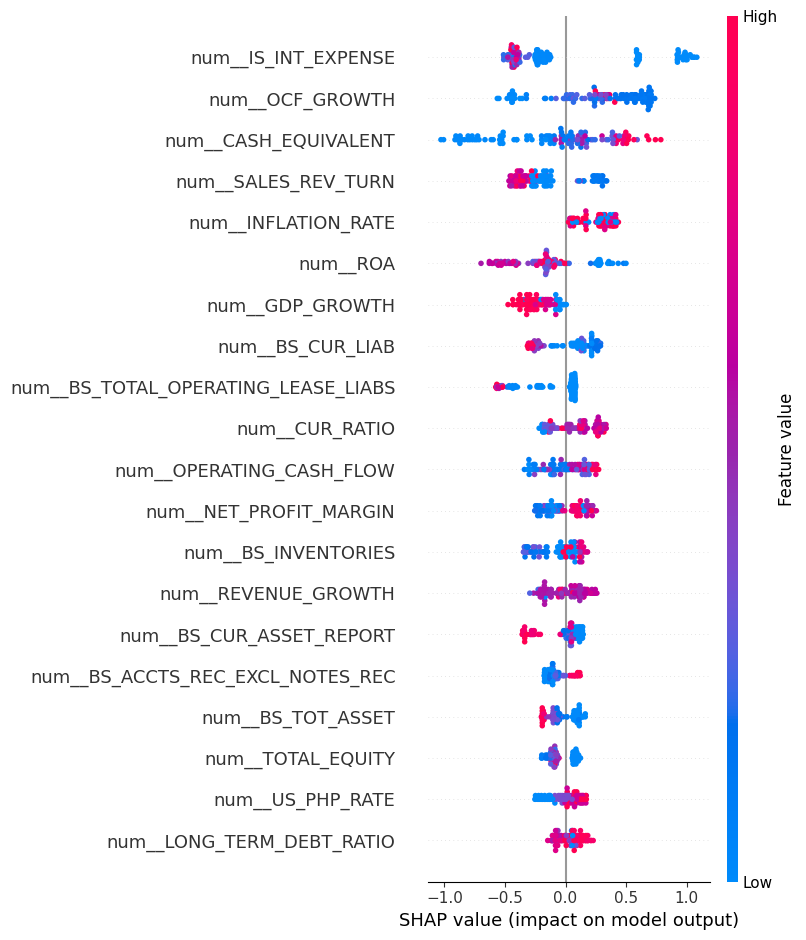

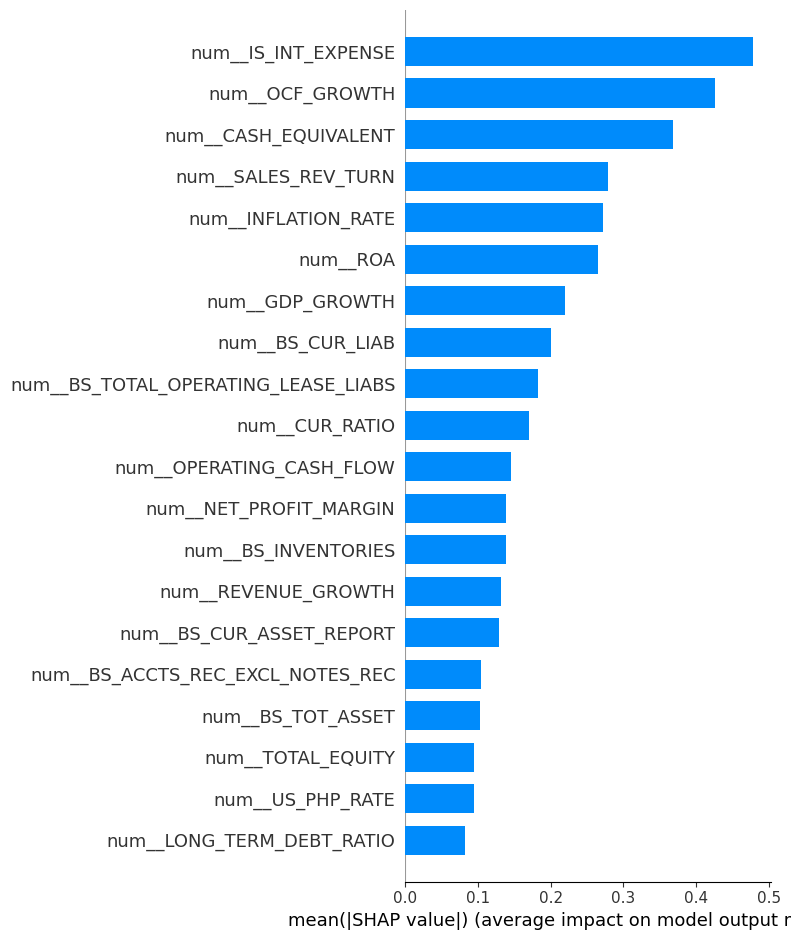

                                Feature  Mean_Absolute_SHAP
10                  num__IS_INT_EXPENSE              0.4782
18                      num__OCF_GROWTH              0.4261
19                 num__CASH_EQUIVALENT              0.3683
8                   num__SALES_REV_TURN              0.2792
24                  num__INFLATION_RATE              0.2723
13                             num__ROA              0.2652
22                      num__GDP_GROWTH              0.2201
1                      num__BS_CUR_LIAB              0.2010
11  num__BS_TOTAL_OPERATING_LEASE_LIABS              0.1829
12                       num__CUR_RATIO              0.1698
17             num__OPERATING_CASH_FLOW              0.1451
14               num__NET_PROFIT_MARGIN              0.1387
2                   num__BS_INVENTORIES              0.1381
20                  num__REVENUE_GROWTH              0.1313
0              num__BS_CUR_ASSET_REPORT              0.1286
6      num__BS_ACCTS_REC_EXCL_NOTES_REC 

In [ ]:
# ============================================================
# XGBOOST USING FINAL DATASETS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

# STEP 1: Load final datasets
train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

target_col = "TARGET_NEXT_QTR"

X_train = train_df[selected_features]
y_train = train_df[target_col]

X_test = test_df[selected_features]
y_test = test_df[target_col]

X_forecast = forecast_df[selected_features]


# STEP 2: Identify feature types

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# STEP 3: Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)


# STEP 4: Base model

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))

])

xgb_model.fit(X_train, y_train)


# STEP 5: Time-series cross-validation

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="roc_auc"
)

print("XGBoost CV ROC-AUC Scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())
print("Std CV ROC-AUC:", cv_scores.std())

cv_df = pd.DataFrame({
    "Fold": np.arange(1, len(cv_scores)+1),
    "ROC_AUC": cv_scores
})

cv_df.loc[len(cv_df)] = [
    "Mean",
    cv_scores.mean()
]

cv_df.to_csv(
    "CrossValidation_XGBoost.csv",
    index=False
)


# STEP 6: Hyperparameter tuning

param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_xgb_model = search.best_estimator_

print("Best Parameters:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)


# ============================================================
# STEP 7: OVERFITTING / UNDERFITTING ASSESSMENT
# XGBoost
# ============================================================

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

train_prob = best_xgb_model.predict_proba(X_train)[:,1]
train_auc = roc_auc_score(y_train, train_prob)

test_prob = best_xgb_model.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, test_prob)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

bias_variance_df = pd.DataFrame({
    "Dataset":[
        "Training",
        "Cross Validation",
        "Testing"
    ],
    "ROC_AUC":[
        train_auc,
        cv_mean,
        test_auc
    ]
})

print(bias_variance_df)

gap = train_auc - test_auc

print(f"\nGeneralization Gap : {gap:.4f}")

if gap < 0.05:
    interpretation = "Excellent generalization. Minimal overfitting."

elif gap < 0.10:
    interpretation = "Slight overfitting but acceptable."

else:
    interpretation = "Possible overfitting detected."

print(interpretation)

bias_variance_df.to_csv(
    "XGBoost_BiasVariance.csv",
    index=False
)

plt.figure(figsize=(6,4))

plt.bar(
    bias_variance_df["Dataset"],
    bias_variance_df["ROC_AUC"]
)

plt.ylim(0,1)

plt.ylabel("ROC-AUC")

plt.title("Bias-Variance Assessment - XGBoost")

plt.show()


# STEP 8: Final test evaluation

y_pred = best_xgb_model.predict(X_test)
y_prob = best_xgb_model.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame({
    "Model": ["XGBoost"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [cv_scores.mean()],
    "CV_ROC_AUC_Std": [cv_scores.std()],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred, zero_division=0)],
    "Recall": [recall_score(y_test, y_pred, zero_division=0)],
    "F1_Score": [f1_score(y_test, y_pred, zero_division=0)],
    "ROC_AUC": [roc_auc_score(y_test, y_prob)]
})

print(metrics_df)
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))
print(classification_report(y_test, y_pred, labels=[0, 1],
                            target_names=["Low Risk", "High Risk"],
                            zero_division=0))

metrics_df.to_csv("XGBoost_Metrics_Tuned_Final.csv", index=False)


# STEP 9: Feature importance

feature_names = best_xgb_model.named_steps["preprocessor"].get_feature_names_out()
importance = best_xgb_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

importance_df.to_csv("XGBoost_FeatureImportance_Tuned_Final.csv", index=False)
print(importance_df.head(20))

# ============================================================
# STEP 10: SHAP EXPLAINABILITY - XGBOOST
# ============================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt

# Transform test data using fitted preprocessor
X_test_transformed = xgb_model.named_steps["preprocessor"].transform(X_test)

feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Get trained XGBoost classifier
xgb_classifier = xgb_model.named_steps["classifier"]

# SHAP Tree Explainer
explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer.shap_values(X_test_shap)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_shap,
    show=True
)

# SHAP bar plot
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=True
)

# Save mean absolute SHAP values
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": abs(shap_values).mean(axis=0)
}).sort_values(by="Mean_Absolute_SHAP", ascending=False)

shap_importance.to_csv(
    "XGBoost_SHAP_Importance_Final.csv",
    index=False
)

print(shap_importance.head(20))

# STEP 11: Predict 2026 Q2
forecast_df["XGB_Probability_High_Risk"] = best_xgb_model.predict_proba(X_forecast)[:, 1]
forecast_df["XGB_Prediction"] = best_xgb_model.predict(X_forecast)
forecast_df["XGB_Risk_Level"] = forecast_df["XGB_Prediction"].map({0: "Low Risk", 1: "High Risk"})

output_cols = [
    "COMPANY_CODE", "FEATURE_YEAR", "FEATURE_QUARTER",
    "PREDICTION_YEAR", "PREDICTION_QUARTER",
    "XGB_Probability_High_Risk", "XGB_Prediction", "XGB_Risk_Level"
]

forecast_df[output_cols].to_csv("XGBoost_2026Q2_Predictions_Tuned_Final.csv", index=False)
print(forecast_df[output_cols])

**Hyperparameter tuning was performed using RandomizedSearchCV with TimeSeriesSplit cross-validation. TimeSeriesSplit was selected to preserve chronological order and avoid look-ahead bias. The best model was selected based on ROC-AUC, which measures the model's ability to distinguish between Low Risk and High Risk companies. Cross-validation results were reported to assess model robustness, while final model performance was evaluated on the 2025 hold-out test set.**

**SHAP analysis was applied to improve model explainability. It identifies the contribution of each financial and macroeconomic variable to the predicted probability of High Risk classification. Variables with higher mean absolute SHAP values have stronger influence on model predictions. Positive SHAP values increase the likelihood of High Risk classification, while negative SHAP values reduce the likelihood of High Risk classification. This improves transparency and supports the use of the model as an early warning tool for debt servicing difficulties.**

**SHAP Waterfall Plot for One Company**

**For Random Forest**

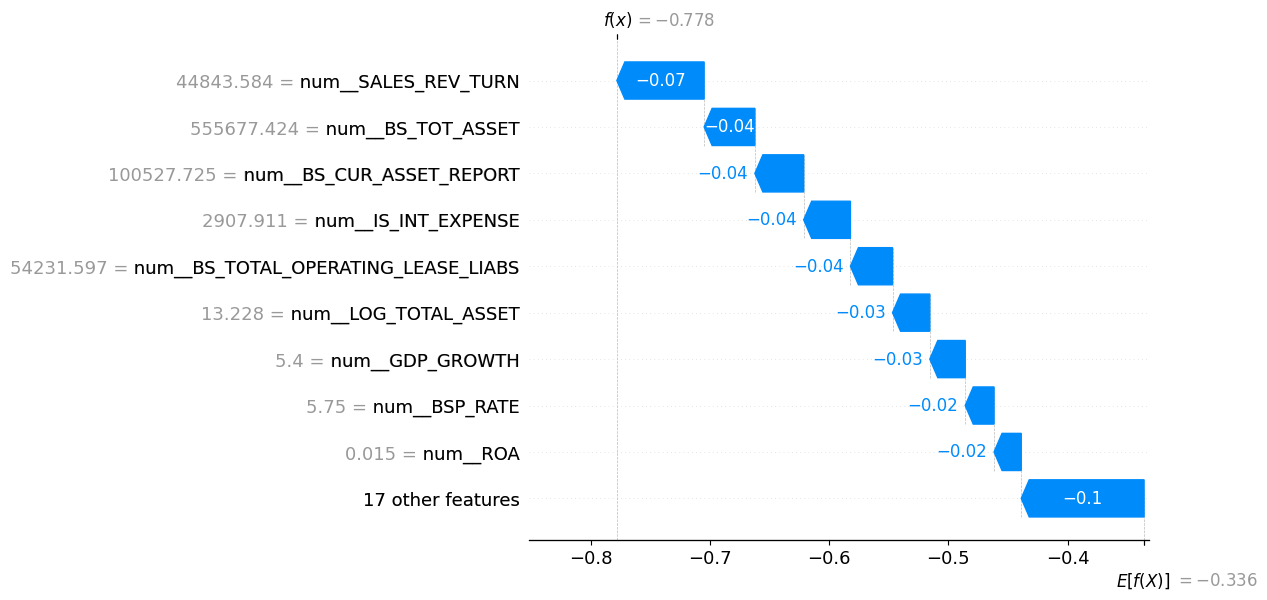

In [ ]:
company_index = 0   # change this to another row if needed

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_high_risk[company_index],
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[company_index],
        feature_names=feature_names
    )
)

**For XGBoost**

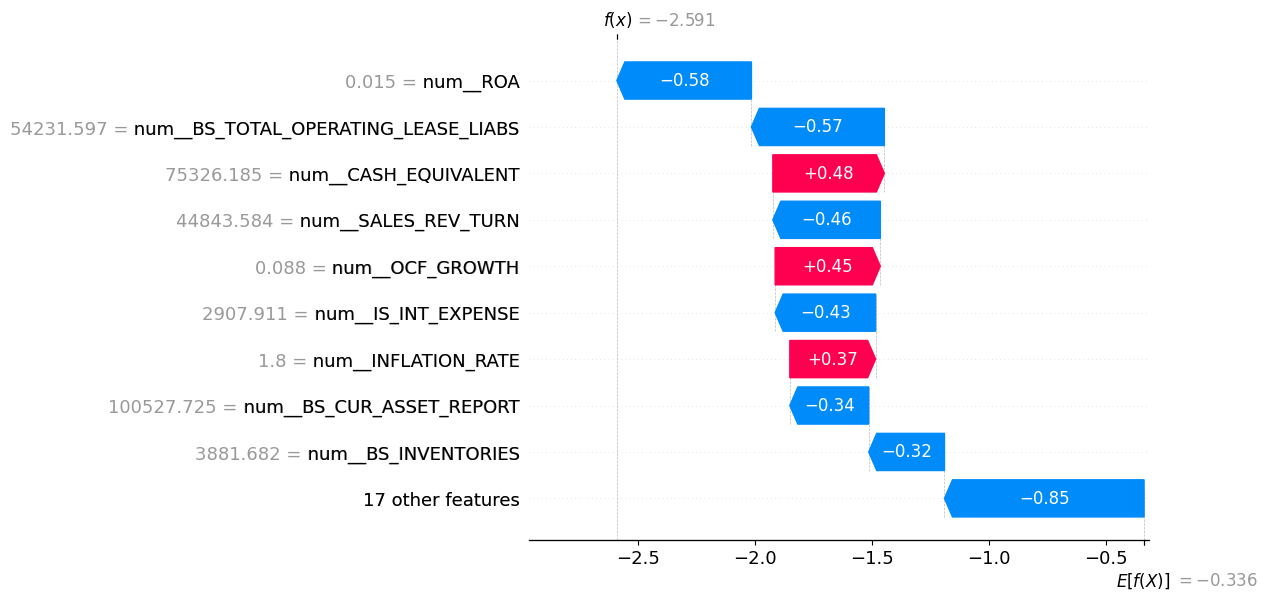

In [ ]:
company_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[company_index],
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[company_index],
        feature_names=feature_names
    )
)

FINAL MODEL COMPARISON
                 Model                                        Best_Params  \
1        Random Forest  {'classifier__n_estimators': 500, 'classifier_...   
2              XGBoost  {'classifier__subsample': 1.0, 'classifier__n_...   
0  Logistic Regression  {'classifier__solver': 'liblinear', 'classifie...   

   CV_ROC_AUC_Mean  CV_ROC_AUC_Std  Accuracy  Precision  Recall  F1_Score  \
1           0.8274          0.0395    0.8583     0.7714  0.7500    0.7606   
2           0.8087          0.0411    0.7833     0.6389  0.6389    0.6389   
0           0.7123          0.0516    0.6000     0.3000  0.2500    0.2727   

   ROC_AUC  
1   0.8343  
2   0.8037  
0   0.6032  

Best Model: Random Forest
Best Test ROC-AUC: 0.8343
Best CV ROC-AUC Mean: 0.8274


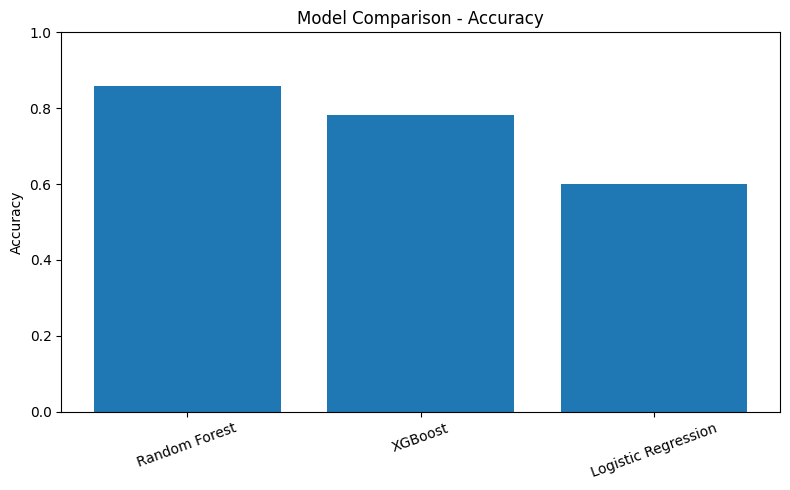

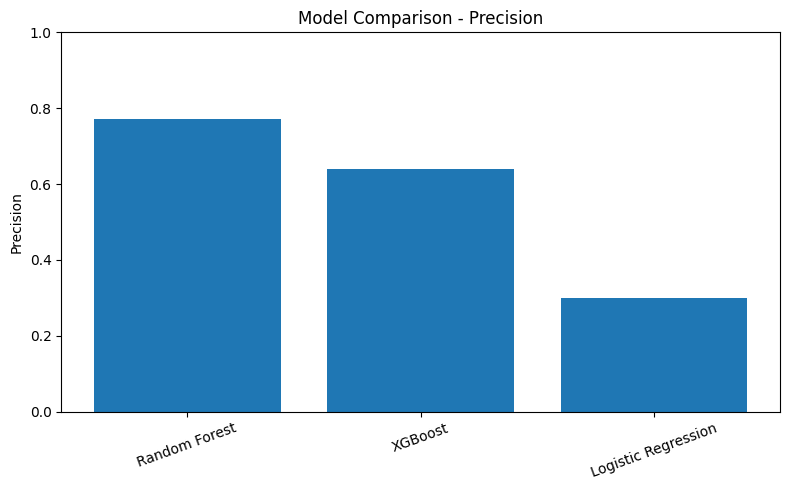

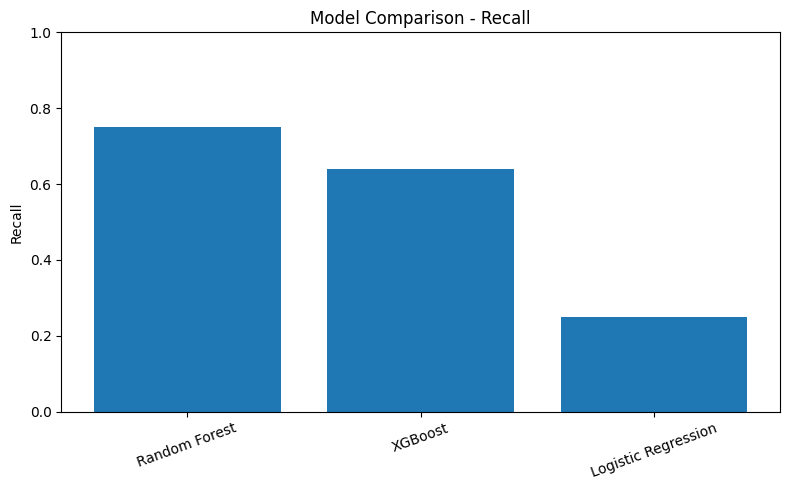

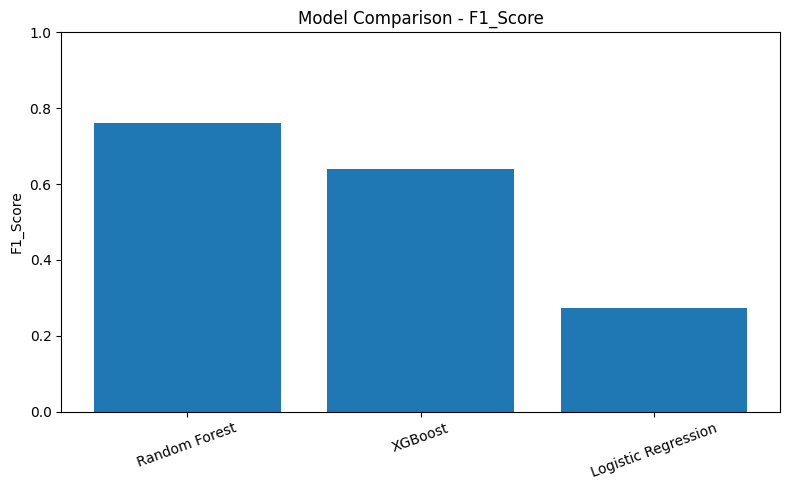

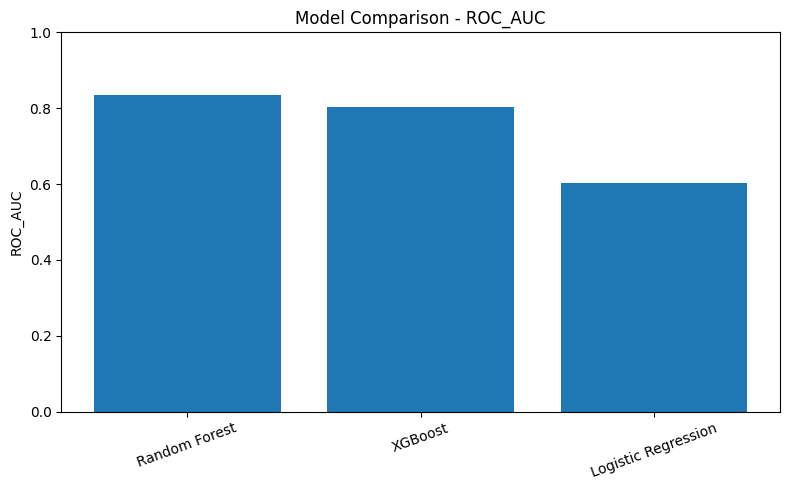

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON - TUNED MODELS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

lr_metrics = pd.read_csv("LogisticRegression_Metrics_Tuned_Final.csv")
rf_metrics = pd.read_csv("RandomForest_Metrics_Tuned_Final.csv")
xgb_metrics = pd.read_csv("XGBoost_Metrics_Tuned_Final.csv")

comparison_df = pd.concat(
    [lr_metrics, rf_metrics, xgb_metrics],
    ignore_index=True
)

metric_cols = [
    "CV_ROC_AUC_Mean",
    "CV_ROC_AUC_Std",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

comparison_df = comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

print("FINAL MODEL COMPARISON")
print(comparison_df)

comparison_df.to_csv("Final_Model_Comparison_Tuned_Final.csv", index=False)

best_model = comparison_df.iloc[0]

print("\nBest Model:", best_model["Model"])
print("Best Test ROC-AUC:", best_model["ROC_AUC"])
print("Best CV ROC-AUC Mean:", best_model["CV_ROC_AUC_Mean"])

for metric in ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["Model"], comparison_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

**Increased Regularization to address overfitting**

Original number of selected features: 26
Number of features after L1 embedded selection: 26
['num__BS_CUR_ASSET_REPORT' 'num__BS_CUR_LIAB' 'num__BS_INVENTORIES'
 'num__BS_TOT_ASSET' 'num__TOTAL_EQUITY' 'num__BS_CASH_NEAR_CASH_ITEM'
 'num__BS_ACCTS_REC_EXCL_NOTES_REC' 'num__NET_INCOME'
 'num__SALES_REV_TURN' 'num__CF_NET_CASH_OPERATING_ACT_CB'
 'num__IS_INT_EXPENSE' 'num__BS_TOTAL_OPERATING_LEASE_LIABS'
 'num__CUR_RATIO' 'num__ROA' 'num__NET_PROFIT_MARGIN'
 'num__DEBT_TO_EQUITY' 'num__LONG_TERM_DEBT_RATIO'
 'num__OPERATING_CASH_FLOW' 'num__OCF_GROWTH' 'num__CASH_EQUIVALENT'
 'num__REVENUE_GROWTH' 'num__LOG_TOTAL_ASSET' 'num__GDP_GROWTH'
 'num__BSP_RATE' 'num__INFLATION_RATE' 'num__US_PHP_RATE']

Baseline CV ROC-AUC Scores: [0.73951049 0.66497748 0.65657143 0.70363409 0.79673423]
Baseline CV ROC-AUC Mean: 0.7122855430013325
Baseline CV ROC-AUC Std : 0.05155529554867657

Best Parameters:
{'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': 0.05}

Best CV ROC-A

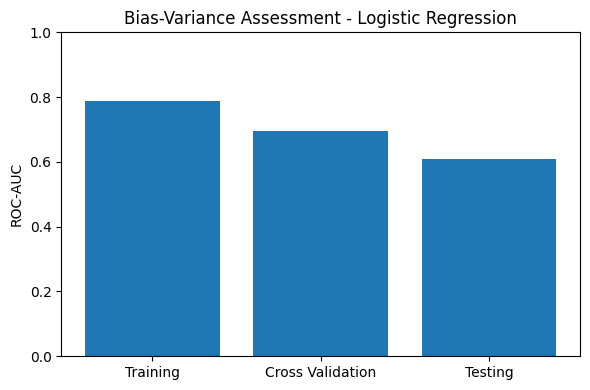


Top 20 Logistic Regression Coefficients:
                                Feature  Coefficient  Absolute_Coefficient
23                        num__BSP_RATE      -0.4529                0.4529
8                   num__SALES_REV_TURN      -0.4176                0.4176
11  num__BS_TOTAL_OPERATING_LEASE_LIABS      -0.3990                0.3990
5           num__BS_CASH_NEAR_CASH_ITEM      -0.3237                0.3237
18                      num__OCF_GROWTH       0.2581                0.2581
21                 num__LOG_TOTAL_ASSET      -0.2282                0.2282
6      num__BS_ACCTS_REC_EXCL_NOTES_REC       0.1977                0.1977
17             num__OPERATING_CASH_FLOW       0.1964                0.1964
24                  num__INFLATION_RATE       0.1378                0.1378
15                  num__DEBT_TO_EQUITY       0.1334                0.1334
20                  num__REVENUE_GROWTH      -0.1323                0.1323
12                       num__CUR_RATIO       0.1200      

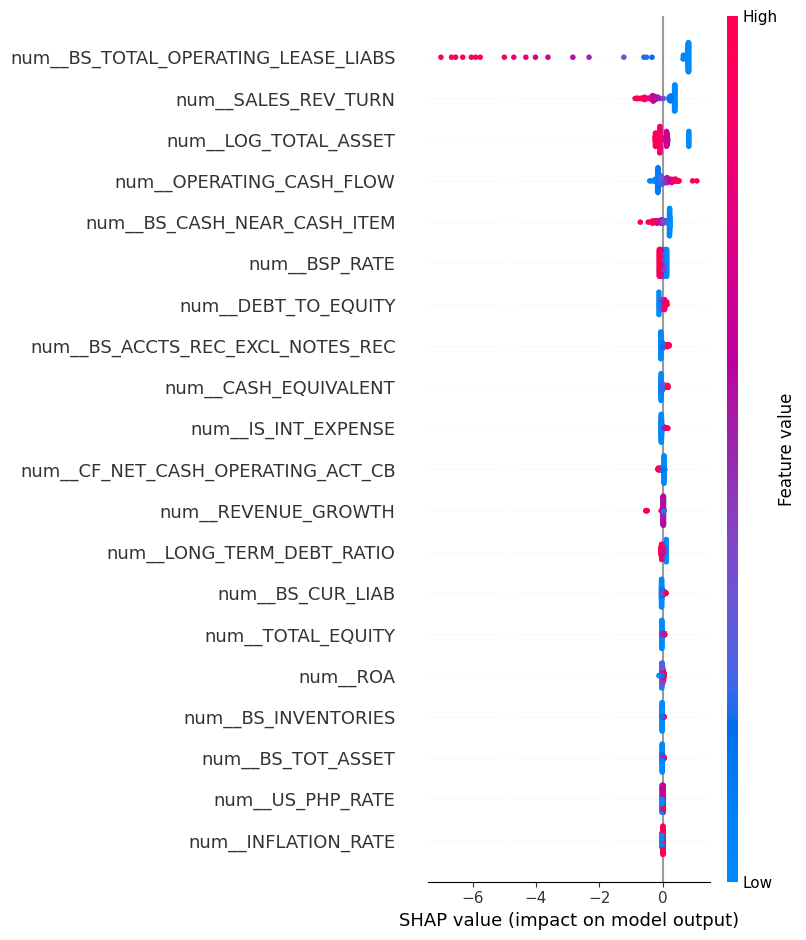

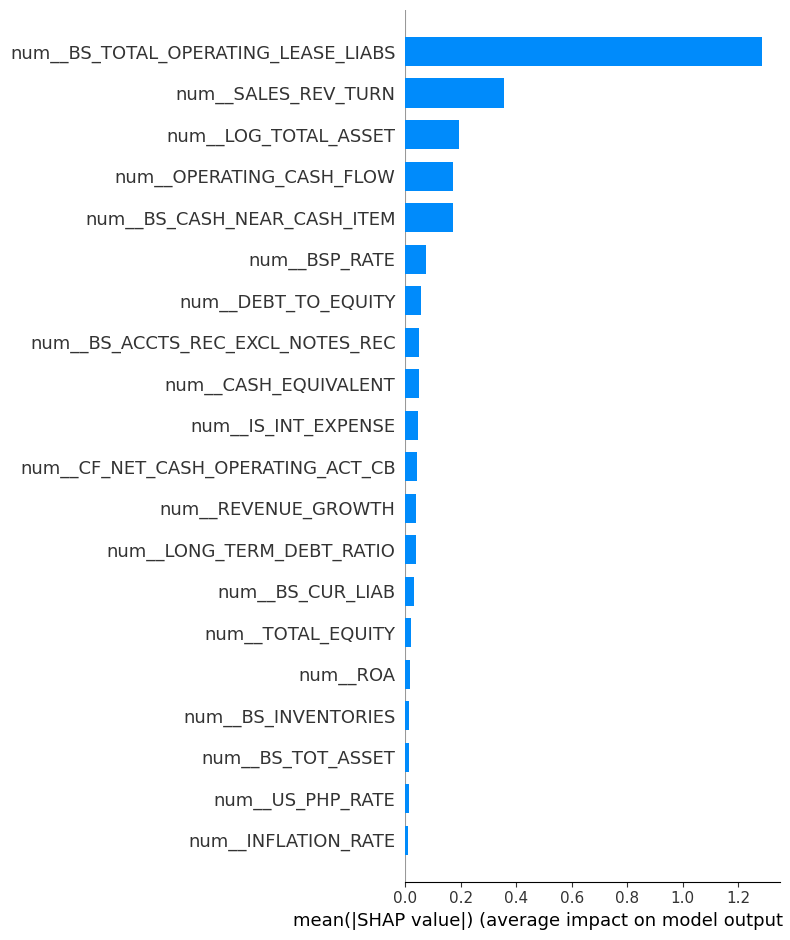


Top 20 SHAP Important Variables:
                                Feature  Mean_Absolute_SHAP
11  num__BS_TOTAL_OPERATING_LEASE_LIABS              1.2861
8                   num__SALES_REV_TURN              0.3555
21                 num__LOG_TOTAL_ASSET              0.1925
17             num__OPERATING_CASH_FLOW              0.1734
5           num__BS_CASH_NEAR_CASH_ITEM              0.1709
23                        num__BSP_RATE              0.0764
15                  num__DEBT_TO_EQUITY              0.0570
6      num__BS_ACCTS_REC_EXCL_NOTES_REC              0.0512
19                 num__CASH_EQUIVALENT              0.0487
10                  num__IS_INT_EXPENSE              0.0456
9     num__CF_NET_CASH_OPERATING_ACT_CB              0.0422
20                  num__REVENUE_GROWTH              0.0388
16            num__LONG_TERM_DEBT_RATIO              0.0373
1                      num__BS_CUR_LIAB              0.0300
4                     num__TOTAL_EQUITY              0.0206
13    

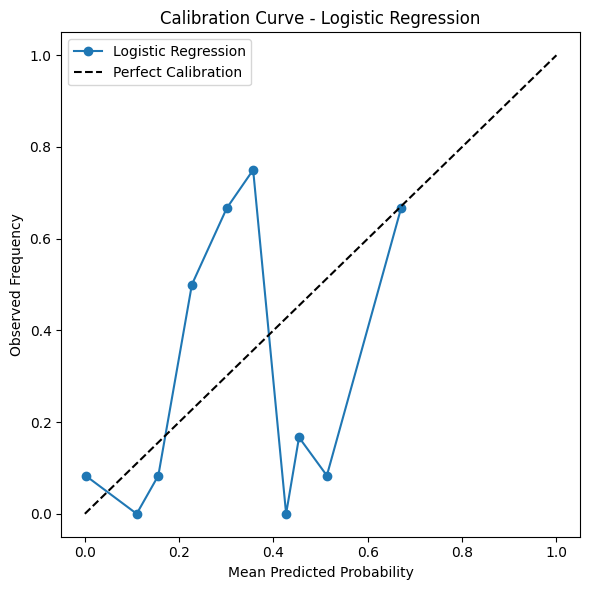


Brier Score: 0.2109

2026 Q2 Forecast:
    COMPANY_CODE  FEATURE_YEAR  FEATURE_QUARTER  PREDICTION_YEAR  \
0              1          2026                1             2026   
1              2          2026                1             2026   
2              3          2026                1             2026   
3              4          2026                1             2026   
4              5          2026                1             2026   
5              6          2026                1             2026   
6              7          2026                1             2026   
7              8          2026                1             2026   
8              9          2026                1             2026   
9             10          2026                1             2026   
10            11          2026                1             2026   
11            12          2026                1             2026   
12            13          2026                1             2026   
13      

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - UPDATED TO REDUCE OVERFITTING
# Final Dataset Version
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, brier_score_loss
)

from sklearn.calibration import calibration_curve

# ============================================================
# STEP 1: LOAD FINAL DATASETS
# ============================================================

train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

target_col = "TARGET_NEXT_QTR"

X_train_full = train_df[selected_features]
y_train = train_df[target_col]

X_test_full = test_df[selected_features]
y_test = test_df[target_col]

X_forecast_full = forecast_df[selected_features]

print("Original number of selected features:", len(selected_features))

# ============================================================
# STEP 2: EMBEDDED FEATURE SELECTION USING L1 LOGISTIC REGRESSION
# ============================================================

numeric_features_full = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_full = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor_for_selection = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features_full),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features_full)
    ]
)

# Transform training data for feature selection
X_train_transformed = preprocessor_for_selection.fit_transform(X_train_full)
feature_names = preprocessor_for_selection.get_feature_names_out()

selector_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.01,                   # strong regularization
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

selector_model.fit(X_train_transformed, y_train)

selector = SelectFromModel(
    selector_model,
    prefit=True,
    threshold="median"
)

selected_mask = selector.get_support()
selected_transformed_features = feature_names[selected_mask]

print("Number of features after L1 embedded selection:", len(selected_transformed_features))
print(selected_transformed_features)

# Save selected transformed features
pd.DataFrame({
    "Selected_Transformed_Features": selected_transformed_features
}).to_csv("LogisticRegression_L1_Selected_Features.csv", index=False)

# Note:
# For modeling pipeline simplicity, we still use the original selected_features,
# but apply stronger regularization in the final model.
# If you want to strictly use only selected transformed features,
# a custom transformed-data pipeline is needed.

# ============================================================
# STEP 3: DEFINE X AND y USING CORRELATION-FILTERED FEATURES
# ============================================================

X_train = X_train_full.copy()
X_test = X_test_full.copy()
X_forecast = X_forecast_full.copy()

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# ============================================================
# STEP 4: PREPROCESSING
# Logistic Regression needs scaling
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# ============================================================
# STEP 5: BASE LOGISTIC REGRESSION MODEL
# ============================================================

logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

# ============================================================
# STEP 6: TIME-SERIES CROSS VALIDATION
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

lr_cv_scores = cross_val_score(
    logreg_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="roc_auc"
)

print("\nBaseline CV ROC-AUC Scores:", lr_cv_scores)
print("Baseline CV ROC-AUC Mean:", lr_cv_scores.mean())
print("Baseline CV ROC-AUC Std :", lr_cv_scores.std())

# ============================================================
# STEP 7: HYPERPARAMETER TUNING
# Stronger regularization to reduce overfitting
# ============================================================

param_grid = {
    "classifier__C": [
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01,
        0.05
    ],
    "classifier__solver": ["liblinear"],
    "classifier__penalty": ["l1", "l2"]
}

search = RandomizedSearchCV(
    estimator=logreg_model,
    param_distributions=param_grid,
    n_iter=12,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_logreg_model = search.best_estimator_

print("\nBest Parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

# ============================================================
# STEP 8: FINAL TEST EVALUATION
# ============================================================

y_pred = best_logreg_model.predict(X_test)
y_prob = best_logreg_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [search.best_score_],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc],
    "Brier_Score": [brier]
})

print("\nFinal Test Metrics:")
print(metrics_df)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Low Risk", "High Risk"],
    zero_division=0
))

metrics_df.to_csv("LogisticRegression_Metrics_Regularized_Final.csv", index=False)

# ============================================================
# STEP 9: OVERFITTING / UNDERFITTING ASSESSMENT
# ============================================================

train_prob = best_logreg_model.predict_proba(X_train)[:, 1]
test_prob = best_logreg_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

generalization_gap = train_auc - test_auc

bias_variance_df = pd.DataFrame({
    "Dataset": ["Training", "Cross Validation", "Testing"],
    "ROC_AUC": [
        train_auc,
        search.best_score_,
        test_auc
    ]
})

print("\nBias-Variance Assessment:")
print(bias_variance_df)

print("\nGeneralization Gap:", round(generalization_gap, 4))

if generalization_gap < 0.05:
    interpretation = "Minimal overfitting. The model generalizes well."
elif generalization_gap < 0.10:
    interpretation = "Slight overfitting but acceptable."
else:
    interpretation = "Possible overfitting remains. Consider reducing features further or retaining Logistic Regression only as a baseline."

print("Interpretation:", interpretation)

bias_variance_df.to_csv("LogisticRegression_BiasVariance_Regularized_Final.csv", index=False)

plt.figure(figsize=(6, 4))
plt.bar(bias_variance_df["Dataset"], bias_variance_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Bias-Variance Assessment - Logistic Regression")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: COEFFICIENT IMPORTANCE
# ============================================================

feature_names = best_logreg_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_logreg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

print("\nTop 20 Logistic Regression Coefficients:")
print(coef_df.head(20))

coef_df.to_csv("LogisticRegression_Coefficients_Regularized_Final.csv", index=False)


# ============================================================
# STEP 11: SHAP EXPLAINABILITY - LOGISTIC REGRESSION
# ============================================================

# Install first if needed:
# pip install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Transform X_test using the fitted preprocessor
# ------------------------------------------------------------

X_test_transformed = best_logreg_model.named_steps["preprocessor"].transform(X_test)

feature_names = best_logreg_model.named_steps["preprocessor"].get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# ------------------------------------------------------------
# Create SHAP explainer for Logistic Regression
# ------------------------------------------------------------

logreg_classifier = best_logreg_model.named_steps["classifier"]

explainer = shap.LinearExplainer(
    logreg_classifier,
    X_test_shap
)

shap_values = explainer.shap_values(X_test_shap)

# ------------------------------------------------------------
# SHAP Summary Plot
# ------------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_test_shap,
    show=True
)

# ------------------------------------------------------------
# SHAP Bar Plot
# Mean absolute SHAP values
# ------------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=True
)

# ------------------------------------------------------------
# Save SHAP Importance Table
# ------------------------------------------------------------

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

print("\nTop 20 SHAP Important Variables:")
print(shap_importance_df.head(20))

shap_importance_df.to_csv(
    "LogisticRegression_SHAP_Importance_Regularized_Final.csv",
    index=False
)


# ============================================================
# STEP 12: CALIBRATION ANALYSIS
# ============================================================

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

calibration_df = pd.DataFrame({
    "Mean_Predicted_Probability": prob_pred,
    "Observed_Frequency": prob_true
})

calibration_df.to_csv("LogisticRegression_Calibration_Regularized_Final.csv", index=False)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

print("\nBrier Score:", round(brier, 4))

# ============================================================
# STEP 13: PREDICT 2026 Q2 USING 2026 Q1 FEATURES
# ============================================================

forecast_df["LR_Probability_High_Risk"] = best_logreg_model.predict_proba(X_forecast)[:, 1]
forecast_df["LR_Prediction"] = best_logreg_model.predict(X_forecast)
forecast_df["LR_Risk_Level"] = forecast_df["LR_Prediction"].map({
    0: "Low Risk",
    1: "High Risk"
})

output_cols = [
    "COMPANY_CODE",
    "FEATURE_YEAR",
    "FEATURE_QUARTER",
    "PREDICTION_YEAR",
    "PREDICTION_QUARTER",
    "LR_Probability_High_Risk",
    "LR_Prediction",
    "LR_Risk_Level"
]

forecast_df[output_cols].to_csv(
    "LogisticRegression_2026Q2_Predictions_Regularized_Final.csv",
    index=False
)

print("\n2026 Q2 Forecast:")
print(forecast_df[output_cols])

**Calibration improves the reliability of predicted probabilities, but it does not necessarily eliminate overfitting. If the generalization gap remains greater than 0.10 after stronger regularization and calibration, the issue may reflect data drift between the training period and the 2025 test period rather than pure model overfitting. In this case, Logistic Regression should be retained as an interpretable baseline model, while model selection should prioritize the algorithm with the strongest test ROC-AUC, recall, and acceptable generalization gap.**

Best Parameters:
{'classifier__penalty': 'l2', 'classifier__C': 0.01}
Best CV ROC-AUC:
0.6901445910182751
                            Model  \
0  Calibrated Logistic Regression   

                                         Best_Params  CV_ROC_AUC_Mean  \
0  {'classifier__penalty': 'l2', 'classifier__C':...           0.6901   

   Accuracy  Precision  Recall  F1_Score  ROC_AUC  Brier_Score  
0    0.7000     0.0000  0.0000    0.0000   0.6187       0.2004  

Confusion Matrix:
[[84  0]
 [36  0]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.70      1.00      0.82        84
   High Risk       0.00      0.00      0.00        36

    accuracy                           0.70       120
   macro avg       0.35      0.50      0.41       120
weighted avg       0.49      0.70      0.58       120


Bias-Variance Assessment:
            Dataset  ROC_AUC
0          Training   0.7429
1  Cross Validation   0.6901
2           Testing   0.6187

Generaliz

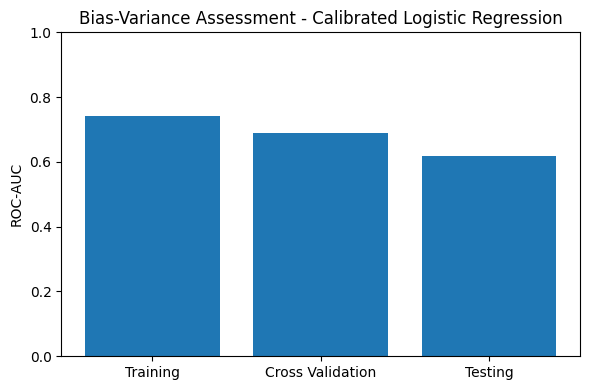

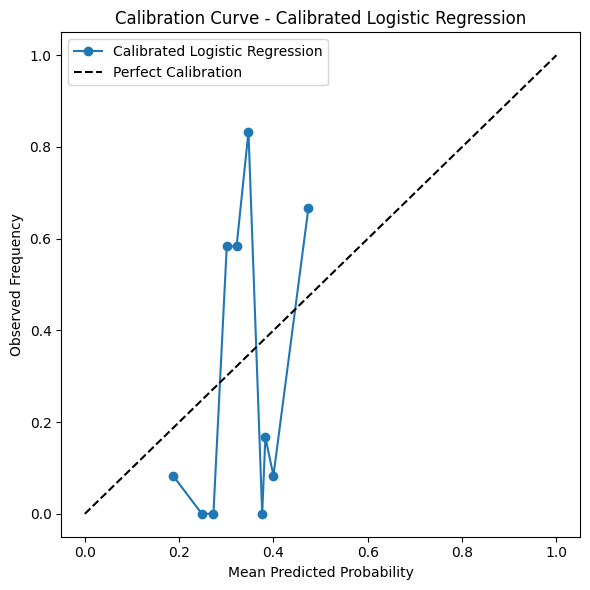

Brier Score: 0.2004
    COMPANY_CODE  FEATURE_YEAR  FEATURE_QUARTER  PREDICTION_YEAR  \
0              1          2026                1             2026   
1              2          2026                1             2026   
2              3          2026                1             2026   
3              4          2026                1             2026   
4              5          2026                1             2026   
5              6          2026                1             2026   
6              7          2026                1             2026   
7              8          2026                1             2026   
8              9          2026                1             2026   
9             10          2026                1             2026   
10            11          2026                1             2026   
11            12          2026                1             2026   
12            13          2026                1             2026   
13            14          20

In [ ]:
# ============================================================
# LOGISTIC REGRESSION WITH STRONG REGULARIZATION + CALIBRATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss
)

# ------------------------------------------------------------
# STEP 1: Load final datasets
# ------------------------------------------------------------

train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

target_col = "TARGET_NEXT_QTR"

X_train = train_df[selected_features]
y_train = train_df[target_col]

X_test = test_df[selected_features]
y_test = test_df[target_col]

X_forecast = forecast_df[selected_features]

# ------------------------------------------------------------
# STEP 2: Identify feature types
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------------------------------------------
# STEP 3: Preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# ------------------------------------------------------------
# STEP 4: Strongly regularized Logistic Regression
# ------------------------------------------------------------

logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

# ------------------------------------------------------------
# STEP 5: Hyperparameter tuning with stronger regularization
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "classifier__C": [
        0.00001,
        0.00005,
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01
    ],
    "classifier__penalty": ["l1", "l2"]
}

search = RandomizedSearchCV(
    estimator=logreg_model,
    param_distributions=param_grid,
    n_iter=14,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_logreg_model = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

print("Best CV ROC-AUC:")
print(search.best_score_)

# ------------------------------------------------------------
# STEP 6: Calibrate the tuned Logistic Regression model
# ------------------------------------------------------------

calibrated_logreg_model = CalibratedClassifierCV(
    estimator=best_logreg_model,
    method="sigmoid",   # safer for small datasets than isotonic
    cv=tscv
)

calibrated_logreg_model.fit(X_train, y_train)

# ------------------------------------------------------------
# STEP 7: Evaluate calibrated model
# ------------------------------------------------------------

y_pred = calibrated_logreg_model.predict(X_test)
y_prob = calibrated_logreg_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Model": ["Calibrated Logistic Regression"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [search.best_score_],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc],
    "Brier_Score": [brier]
})

print(metrics_df)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Low Risk", "High Risk"],
    zero_division=0
))

metrics_df.to_csv("Calibrated_LogisticRegression_Metrics_Final.csv", index=False)

# ------------------------------------------------------------
# STEP 8: Bias-Variance / Overfitting Check
# ------------------------------------------------------------

train_prob = calibrated_logreg_model.predict_proba(X_train)[:, 1]
test_prob = calibrated_logreg_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

generalization_gap = train_auc - test_auc

bias_variance_df = pd.DataFrame({
    "Dataset": ["Training", "Cross Validation", "Testing"],
    "ROC_AUC": [train_auc, search.best_score_, test_auc]
})

print("\nBias-Variance Assessment:")
print(bias_variance_df)

print("\nGeneralization Gap:", round(generalization_gap, 4))

if generalization_gap < 0.05:
    print("Interpretation: Minimal overfitting.")
elif generalization_gap < 0.10:
    print("Interpretation: Slight but acceptable overfitting.")
else:
    print("Interpretation: Generalization gap remains high. This may indicate data drift between training and 2025 test data.")

bias_variance_df.to_csv("Calibrated_LogisticRegression_BiasVariance_Final.csv", index=False)

plt.figure(figsize=(6, 4))
plt.bar(bias_variance_df["Dataset"], bias_variance_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Bias-Variance Assessment - Calibrated Logistic Regression")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 9: Calibration Curve
# ------------------------------------------------------------

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

calibration_df = pd.DataFrame({
    "Mean_Predicted_Probability": prob_pred,
    "Observed_Frequency": prob_true
})

calibration_df.to_csv("Calibrated_LogisticRegression_Calibration_Final.csv", index=False)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Calibrated Logistic Regression")
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve - Calibrated Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

print("Brier Score:", round(brier, 4))

# ------------------------------------------------------------
# STEP 10: Predict 2026 Q2 using calibrated model
# ------------------------------------------------------------

forecast_df["LR_Probability_High_Risk"] = calibrated_logreg_model.predict_proba(X_forecast)[:, 1]
forecast_df["LR_Prediction"] = calibrated_logreg_model.predict(X_forecast)

forecast_df["LR_Risk_Level"] = forecast_df["LR_Prediction"].map({
    0: "Low Risk",
    1: "High Risk"
})

output_cols = [
    "COMPANY_CODE",
    "FEATURE_YEAR",
    "FEATURE_QUARTER",
    "PREDICTION_YEAR",
    "PREDICTION_QUARTER",
    "LR_Probability_High_Risk",
    "LR_Prediction",
    "LR_Risk_Level"
]

forecast_df[output_cols].to_csv(
    "Calibrated_LogisticRegression_2026Q2_Predictions_Final.csv",
    index=False
)

print(forecast_df[output_cols])

This version is stricter because it:

keeps only 5 to 15 strongest variables;
uses very small C values for stronger regularization;
allows L1 and Elastic Net, which can shrink weak coefficients to zero;
tests whether class_weight="balanced" is helping or hurting;
performs feature selection inside the cross-validation pipeline, which avoids feature-selection leakage. **bold text**

Best Parameters:
{'feature_selection__k': 15, 'classifier__penalty': 'l2', 'classifier__l1_ratio': 0.2, 'classifier__class_weight': 'balanced', 'classifier__C': 0.001}

Best CV ROC-AUC:
0.6813494271494271

Final Test Metrics:
                                    Model  \
0  Logistic Regression - Anti Overfitting   

                                         Best_Params  CV_ROC_AUC_Mean  \
0  {'feature_selection__k': 15, 'classifier__pena...           0.6813   

   Accuracy  Precision  Recall  F1_Score  ROC_AUC  Brier_Score  
0    0.5167     0.2963  0.4444    0.3556   0.6025       0.2337  

Confusion Matrix:
[[46 38]
 [20 16]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.70      0.55      0.61        84
   High Risk       0.30      0.44      0.36        36

    accuracy                           0.52       120
   macro avg       0.50      0.50      0.48       120
weighted avg       0.58      0.52      0.54       120


Bias-Variance As

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


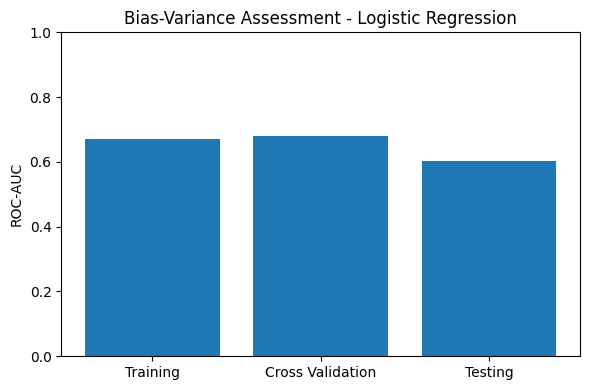


Final selected features used by Logistic Regression:
                     Selected_Feature
0            num__BS_CUR_ASSET_REPORT
1                    num__BS_CUR_LIAB
2                   num__BS_TOT_ASSET
3                   num__TOTAL_EQUITY
4         num__BS_CASH_NEAR_CASH_ITEM
5    num__BS_ACCTS_REC_EXCL_NOTES_REC
6                 num__SALES_REV_TURN
7   num__CF_NET_CASH_OPERATING_ACT_CB
8                 num__IS_INT_EXPENSE
9                            num__ROA
10             num__NET_PROFIT_MARGIN
11               num__LOG_TOTAL_ASSET
12                    num__GDP_GROWTH
13                num__INFLATION_RATE
14                   num__US_PHP_RATE

Top Logistic Regression Coefficients:
                              Feature  Coefficient  Absolute_Coefficient
6                 num__SALES_REV_TURN      -0.0590                0.0590
4         num__BS_CASH_NEAR_CASH_ITEM      -0.0551                0.0551
11               num__LOG_TOTAL_ASSET      -0.0427                0.0427
14     

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - ANTI-OVERFITTING VERSION
# Uses final datasets + feature selection inside pipeline
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss
)

# ------------------------------------------------------------
# STEP 1: Load final datasets
# ------------------------------------------------------------

train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

target_col = "TARGET_NEXT_QTR"

X_train = train_df[selected_features]
y_train = train_df[target_col]

X_test = test_df[selected_features]
y_test = test_df[target_col]

X_forecast = forecast_df[selected_features]

# ------------------------------------------------------------
# STEP 2: Identify feature types
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------------------------------------------
# STEP 3: Preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# ------------------------------------------------------------
# STEP 4: Logistic Regression Pipeline
# Feature selection is inside the pipeline to avoid leakage
# ------------------------------------------------------------

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    # Select only the most informative variables
    ("feature_selection", SelectKBest(
        score_func=mutual_info_classif
    )),

    ("classifier", LogisticRegression(
        max_iter=10000,
        solver="saga",
        random_state=42
    ))
])

# ------------------------------------------------------------
# STEP 5: Time-Series Cross Validation
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=5)

# ------------------------------------------------------------
# STEP 6: Hyperparameter Tuning
# Strong regularization + fewer variables
# ------------------------------------------------------------

param_grid = {
    "feature_selection__k": [5, 8, 10, 12, 15],

    "classifier__penalty": ["l1", "l2", "elasticnet"],

    "classifier__C": [
        0.00001,
        0.00005,
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01
    ],

    "classifier__l1_ratio": [0.2, 0.5, 0.8],

    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

search.fit(X_train, y_train)

best_logreg_model = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

# ------------------------------------------------------------
# STEP 7: Final Test Evaluation
# ------------------------------------------------------------

y_pred = best_logreg_model.predict(X_test)
y_prob = best_logreg_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression - Anti Overfitting"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [search.best_score_],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc],
    "Brier_Score": [brier]
})

print("\nFinal Test Metrics:")
print(metrics_df)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Low Risk", "High Risk"],
    zero_division=0
))

metrics_df.to_csv(
    "LogisticRegression_AntiOverfitting_Metrics_Final.csv",
    index=False
)

# ------------------------------------------------------------
# STEP 8: Bias-Variance / Overfitting Assessment
# ------------------------------------------------------------

train_prob = best_logreg_model.predict_proba(X_train)[:, 1]
test_prob = best_logreg_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

generalization_gap = train_auc - test_auc

bias_variance_df = pd.DataFrame({
    "Dataset": [
        "Training",
        "Cross Validation",
        "Testing"
    ],
    "ROC_AUC": [
        train_auc,
        search.best_score_,
        test_auc
    ]
})

print("\nBias-Variance Assessment:")
print(bias_variance_df)

print("\nGeneralization Gap:", round(generalization_gap, 4))

if generalization_gap < 0.05:
    print("Interpretation: Minimal overfitting. The model generalizes well.")
elif generalization_gap < 0.10:
    print("Interpretation: Slight overfitting but acceptable.")
else:
    print("Interpretation: Generalization gap remains high. This may indicate data drift or structural difference between training and 2025 test data.")

bias_variance_df.to_csv(
    "LogisticRegression_AntiOverfitting_BiasVariance_Final.csv",
    index=False
)

plt.figure(figsize=(6, 4))
plt.bar(bias_variance_df["Dataset"], bias_variance_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Bias-Variance Assessment - Logistic Regression")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 9: Selected Features
# ------------------------------------------------------------

all_feature_names = best_logreg_model.named_steps["preprocessor"].get_feature_names_out()

selected_mask = best_logreg_model.named_steps["feature_selection"].get_support()

selected_model_features = all_feature_names[selected_mask]

selected_model_features_df = pd.DataFrame({
    "Selected_Feature": selected_model_features
})

print("\nFinal selected features used by Logistic Regression:")
print(selected_model_features_df)

selected_model_features_df.to_csv(
    "LogisticRegression_Final_Selected_Features.csv",
    index=False
)

# ------------------------------------------------------------
# STEP 10: Coefficient Importance
# ------------------------------------------------------------

coefficients = best_logreg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": selected_model_features,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

print("\nTop Logistic Regression Coefficients:")
print(coef_df)

coef_df.to_csv(
    "LogisticRegression_AntiOverfitting_Coefficients_Final.csv",
    index=False
)

# ------------------------------------------------------------
# STEP 11: Predict 2026 Q2 Using 2026 Q1 Features
# ------------------------------------------------------------

forecast_df["LR_Probability_High_Risk"] = best_logreg_model.predict_proba(X_forecast)[:, 1]
forecast_df["LR_Prediction"] = best_logreg_model.predict(X_forecast)

forecast_df["LR_Risk_Level"] = forecast_df["LR_Prediction"].map({
    0: "Low Risk",
    1: "High Risk"
})

output_cols = [
    "COMPANY_CODE",
    "FEATURE_YEAR",
    "FEATURE_QUARTER",
    "PREDICTION_YEAR",
    "PREDICTION_QUARTER",
    "LR_Probability_High_Risk",
    "LR_Prediction",
    "LR_Risk_Level"
]

forecast_df[output_cols].to_csv(
    "LogisticRegression_AntiOverfitting_2026Q2_Predictions_Final.csv",
    index=False
)

print("\n2026 Q2 Forecast:")
print(forecast_df[output_cols])

Best Parameters:
{'feature_selection__k': 12, 'classifier__n_estimators': 200, 'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 0.3, 'classifier__max_depth': 4, 'classifier__bootstrap': True}

Best CV ROC-AUC:
0.8153978282504599

Final Test Metrics:
                              Model  \
0  Random Forest - Anti Overfitting   

                                         Best_Params  CV_ROC_AUC_Mean  \
0  {'feature_selection__k': 12, 'classifier__n_es...           0.8154   

   Accuracy  Precision  Recall  F1_Score  ROC_AUC  Brier_Score  
0    0.8750     0.8182  0.7500    0.7826   0.8532       0.1439  

Confusion Matrix:
[[78  6]
 [ 9 27]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.93      0.91        84
   High Risk       0.82      0.75      0.78        36

    accuracy                           0.88       120
   macro avg       0.86      0.84      0.85       120
weighted

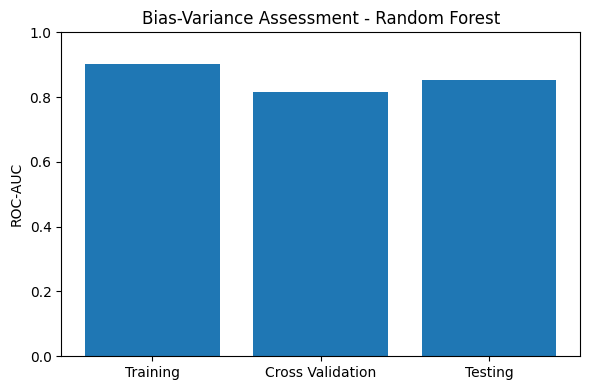


Final selected features used by Random Forest:
                    Selected_Feature
0           num__BS_CUR_ASSET_REPORT
1                   num__BS_CUR_LIAB
2                  num__BS_TOT_ASSET
3                  num__TOTAL_EQUITY
4        num__BS_CASH_NEAR_CASH_ITEM
5   num__BS_ACCTS_REC_EXCL_NOTES_REC
6                num__SALES_REV_TURN
7                num__IS_INT_EXPENSE
8                           num__ROA
9               num__LOG_TOTAL_ASSET
10                   num__GDP_GROWTH
11               num__INFLATION_RATE

Top Random Forest Feature Importance:
                             Feature  Importance
7                num__IS_INT_EXPENSE      0.1668
6                num__SALES_REV_TURN      0.1487
10                   num__GDP_GROWTH      0.1064
8                           num__ROA      0.0952
0           num__BS_CUR_ASSET_REPORT      0.0899
2                  num__BS_TOT_ASSET      0.0703
4        num__BS_CASH_NEAR_CASH_ITEM      0.0667
9               num__LOG_TOTAL_ASSET    

In [ ]:
# ============================================================
# RANDOM FOREST - ANTI-OVERFITTING VERSION
# Uses final datasets + feature selection inside pipeline
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss
)

# STEP 1: Load final datasets
train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

target_col = "TARGET_NEXT_QTR"

X_train = train_df[selected_features]
y_train = train_df[target_col]

X_test = test_df[selected_features]
y_test = test_df[target_col]

X_forecast = forecast_df[selected_features]

# STEP 2: Identify feature types
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# STEP 3: Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# STEP 4: Pipeline with feature selection inside CV
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("feature_selection", SelectKBest(
        score_func=mutual_info_classif
    )),

    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# STEP 5: Time-series CV
tscv = TimeSeriesSplit(n_splits=5)

# STEP 6: Hyperparameter tuning - restricted to reduce overfitting
param_grid = {
    "feature_selection__k": [5, 8, 10, 12, 15],

    "classifier__n_estimators": [100, 150, 200],

    # shallow trees to reduce overfitting
    "classifier__max_depth": [2, 3, 4, 5],

    # larger split/leaf sizes reduce memorization
    "classifier__min_samples_split": [20, 30, 40, 50],
    "classifier__min_samples_leaf": [10, 15, 20, 30],

    # limit number of features used per split
    "classifier__max_features": [0.3, 0.5, "sqrt"],

    # add randomness / regularization
    "classifier__bootstrap": [True]
}

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

search.fit(X_train, y_train)

best_rf_model = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

# STEP 7: Final test evaluation
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Model": ["Random Forest - Anti Overfitting"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [search.best_score_],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc],
    "Brier_Score": [brier]
})

print("\nFinal Test Metrics:")
print(metrics_df)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Low Risk", "High Risk"],
    zero_division=0
))

metrics_df.to_csv(
    "RandomForest_AntiOverfitting_Metrics_Final.csv",
    index=False
)

# STEP 8: Bias-Variance / Overfitting Assessment
train_prob = best_rf_model.predict_proba(X_train)[:, 1]
test_prob = best_rf_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

generalization_gap = train_auc - test_auc

bias_variance_df = pd.DataFrame({
    "Dataset": ["Training", "Cross Validation", "Testing"],
    "ROC_AUC": [train_auc, search.best_score_, test_auc]
})

print("\nBias-Variance Assessment:")
print(bias_variance_df)

print("\nGeneralization Gap:", round(generalization_gap, 4))

if generalization_gap < 0.05:
    print("Interpretation: Minimal overfitting. The model generalizes well.")
elif generalization_gap < 0.10:
    print("Interpretation: Slight overfitting but acceptable.")
else:
    print("Interpretation: Generalization gap remains high. Consider stronger restrictions or possible data drift.")

bias_variance_df.to_csv(
    "RandomForest_AntiOverfitting_BiasVariance_Final.csv",
    index=False
)

plt.figure(figsize=(6, 4))
plt.bar(bias_variance_df["Dataset"], bias_variance_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Bias-Variance Assessment - Random Forest")
plt.tight_layout()
plt.show()

# STEP 9: Selected features
all_feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
selected_mask = best_rf_model.named_steps["feature_selection"].get_support()
selected_model_features = all_feature_names[selected_mask]

selected_model_features_df = pd.DataFrame({
    "Selected_Feature": selected_model_features
})

print("\nFinal selected features used by Random Forest:")
print(selected_model_features_df)

selected_model_features_df.to_csv(
    "RandomForest_Final_Selected_Features.csv",
    index=False
)

# STEP 10: Feature importance
rf_classifier = best_rf_model.named_steps["classifier"]

importance_df = pd.DataFrame({
    "Feature": selected_model_features,
    "Importance": rf_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Random Forest Feature Importance:")
print(importance_df.head(20))

importance_df.to_csv(
    "RandomForest_AntiOverfitting_FeatureImportance_Final.csv",
    index=False
)

# STEP 11: Predict 2026 Q2
forecast_df["RF_Probability_High_Risk"] = best_rf_model.predict_proba(X_forecast)[:, 1]
forecast_df["RF_Prediction"] = best_rf_model.predict(X_forecast)

forecast_df["RF_Risk_Level"] = forecast_df["RF_Prediction"].map({
    0: "Low Risk",
    1: "High Risk"
})

output_cols = [
    "COMPANY_CODE",
    "FEATURE_YEAR",
    "FEATURE_QUARTER",
    "PREDICTION_YEAR",
    "PREDICTION_QUARTER",
    "RF_Probability_High_Risk",
    "RF_Prediction",
    "RF_Risk_Level"
]

forecast_df[output_cols].to_csv(
    "RandomForest_AntiOverfitting_2026Q2_Predictions_Final.csv",
    index=False
)

print("\n2026 Q2 Forecast:")
print(forecast_df[output_cols])

Best Parameters:
{'feature_selection__k': 15, 'classifier__subsample': 0.8, 'classifier__reg_lambda': 10, 'classifier__reg_alpha': 1, 'classifier__n_estimators': 100, 'classifier__min_child_weight': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__gamma': 1, 'classifier__colsample_bytree': 0.5}

Best CV ROC-AUC:
0.7988431935063514

Final Test Metrics:
                        Model  \
0  XGBoost - Anti Overfitting   

                                         Best_Params  CV_ROC_AUC_Mean  \
0  {'feature_selection__k': 15, 'classifier__subs...           0.7988   

   Accuracy  Precision  Recall  F1_Score  ROC_AUC  Brier_Score  
0    0.8750     0.8182  0.7500    0.7826   0.8439       0.1328  

Confusion Matrix:
[[78  6]
 [ 9 27]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.93      0.91        84
   High Risk       0.82      0.75      0.78        36

    accuracy                           0.88   

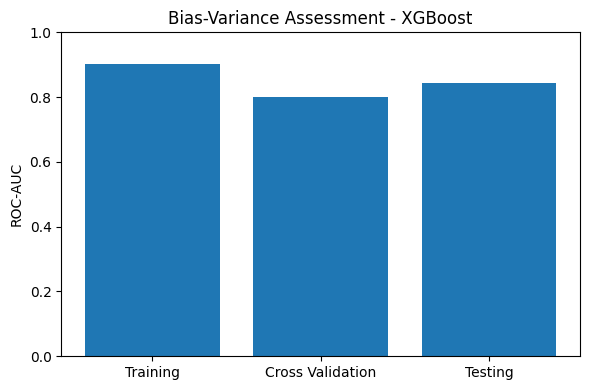


Final selected features used by XGBoost:
                    Selected_Feature
0           num__BS_CUR_ASSET_REPORT
1                   num__BS_CUR_LIAB
2                  num__BS_TOT_ASSET
3                  num__TOTAL_EQUITY
4        num__BS_CASH_NEAR_CASH_ITEM
5   num__BS_ACCTS_REC_EXCL_NOTES_REC
6                num__SALES_REV_TURN
7                num__IS_INT_EXPENSE
8                           num__ROA
9             num__NET_PROFIT_MARGIN
10              num__LOG_TOTAL_ASSET
11                   num__GDP_GROWTH
12                     num__BSP_RATE
13               num__INFLATION_RATE
14                  num__US_PHP_RATE

Top XGBoost Feature Importance:
                             Feature  Importance
7                num__IS_INT_EXPENSE      0.1613
12                     num__BSP_RATE      0.1330
10              num__LOG_TOTAL_ASSET      0.0881
6                num__SALES_REV_TURN      0.0756
8                           num__ROA      0.0704
2                  num__BS_TOT_ASSET   

In [ ]:
# ============================================================
# XGBOOST - ANTI-OVERFITTING VERSION
# Uses final datasets + feature selection inside pipeline
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss
)

from xgboost import XGBClassifier

# STEP 1: Load final datasets
train_df = pd.read_csv("Train_Data_2020Q4_to_2024Q4.csv")
test_df = pd.read_csv("Test_Data_2025Q1_to_2025Q4.csv")
forecast_df = pd.read_csv("Forecast_Input_2026Q1_for_2026Q2.csv")

selected_features_df = pd.read_csv("Selected_Features_Correlation_Filter.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

target_col = "TARGET_NEXT_QTR"

X_train = train_df[selected_features]
y_train = train_df[target_col]

X_test = test_df[selected_features]
y_test = test_df[target_col]

X_forecast = forecast_df[selected_features]

# STEP 2: Identify feature types
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# STEP 3: Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# STEP 4: Pipeline with feature selection inside CV
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("feature_selection", SelectKBest(
        score_func=mutual_info_classif
    )),

    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# STEP 5: Time-series CV
tscv = TimeSeriesSplit(n_splits=5)

# STEP 6: Hyperparameter tuning - stronger regularization
param_grid = {
    "feature_selection__k": [5, 8, 10, 12, 15],

    # fewer trees and lower learning rate
    "classifier__n_estimators": [50, 100, 150, 200],
    "classifier__learning_rate": [0.005, 0.01, 0.03, 0.05],

    # shallow trees reduce overfitting
    "classifier__max_depth": [1, 2, 3],

    # stronger child weight
    "classifier__min_child_weight": [5, 10, 15, 20],

    # row and column subsampling reduce variance
    "classifier__subsample": [0.5, 0.6, 0.7, 0.8],
    "classifier__colsample_bytree": [0.5, 0.6, 0.7, 0.8],

    # split regularization
    "classifier__gamma": [0, 1, 3, 5, 10],

    # L1 and L2 regularization
    "classifier__reg_alpha": [0, 0.5, 1, 2, 5],
    "classifier__reg_lambda": [1, 3, 5, 10, 20]
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

search.fit(X_train, y_train)

best_xgb_model = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

# STEP 7: Final test evaluation
y_pred = best_xgb_model.predict(X_test)
y_prob = best_xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Model": ["XGBoost - Anti Overfitting"],
    "Best_Params": [str(search.best_params_)],
    "CV_ROC_AUC_Mean": [search.best_score_],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc],
    "Brier_Score": [brier]
})

print("\nFinal Test Metrics:")
print(metrics_df)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Low Risk", "High Risk"],
    zero_division=0
))

metrics_df.to_csv(
    "XGBoost_AntiOverfitting_Metrics_Final.csv",
    index=False
)

# STEP 8: Bias-Variance / Overfitting Assessment
train_prob = best_xgb_model.predict_proba(X_train)[:, 1]
test_prob = best_xgb_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

generalization_gap = train_auc - test_auc

bias_variance_df = pd.DataFrame({
    "Dataset": ["Training", "Cross Validation", "Testing"],
    "ROC_AUC": [train_auc, search.best_score_, test_auc]
})

print("\nBias-Variance Assessment:")
print(bias_variance_df)

print("\nGeneralization Gap:", round(generalization_gap, 4))

if generalization_gap < 0.05:
    print("Interpretation: Minimal overfitting. The model generalizes well.")
elif generalization_gap < 0.10:
    print("Interpretation: Slight overfitting but acceptable.")
else:
    print("Interpretation: Generalization gap remains high. Consider stronger regularization or possible data drift.")

bias_variance_df.to_csv(
    "XGBoost_AntiOverfitting_BiasVariance_Final.csv",
    index=False
)

plt.figure(figsize=(6, 4))
plt.bar(bias_variance_df["Dataset"], bias_variance_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Bias-Variance Assessment - XGBoost")
plt.tight_layout()
plt.show()

# STEP 9: Selected features
all_feature_names = best_xgb_model.named_steps["preprocessor"].get_feature_names_out()
selected_mask = best_xgb_model.named_steps["feature_selection"].get_support()
selected_model_features = all_feature_names[selected_mask]

selected_model_features_df = pd.DataFrame({
    "Selected_Feature": selected_model_features
})

print("\nFinal selected features used by XGBoost:")
print(selected_model_features_df)

selected_model_features_df.to_csv(
    "XGBoost_Final_Selected_Features.csv",
    index=False
)

# STEP 10: Feature importance
xgb_classifier = best_xgb_model.named_steps["classifier"]

importance_df = pd.DataFrame({
    "Feature": selected_model_features,
    "Importance": xgb_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop XGBoost Feature Importance:")
print(importance_df.head(20))

importance_df.to_csv(
    "XGBoost_AntiOverfitting_FeatureImportance_Final.csv",
    index=False
)

# STEP 11: Predict 2026 Q2
forecast_df["XGB_Probability_High_Risk"] = best_xgb_model.predict_proba(X_forecast)[:, 1]
forecast_df["XGB_Prediction"] = best_xgb_model.predict(X_forecast)

forecast_df["XGB_Risk_Level"] = forecast_df["XGB_Prediction"].map({
    0: "Low Risk",
    1: "High Risk"
})

output_cols = [
    "COMPANY_CODE",
    "FEATURE_YEAR",
    "FEATURE_QUARTER",
    "PREDICTION_YEAR",
    "PREDICTION_QUARTER",
    "XGB_Probability_High_Risk",
    "XGB_Prediction",
    "XGB_Risk_Level"
]

forecast_df[output_cols].to_csv(
    "XGBoost_AntiOverfitting_2026Q2_Predictions_Final.csv",
    index=False
)

print("\n2026 Q2 Forecast:")
print(forecast_df[output_cols])

FINAL MODEL COMPARISON


,Model,Best_Params,CV_ROC_AUC_Mean,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Brier_Score,Generalization_Gap
1,Random Forest - Anti Overfitting,"{'feature_selection__k': 12, 'classifier__n_es...",0.8154,0.8750,0.8182,0.7500,0.7826,0.8532,0.1439,0.0486
2,XGBoost - Anti Overfitting,"{'feature_selection__k': 15, 'classifier__subs...",0.7988,0.8750,0.8182,0.7500,0.7826,0.8439,0.1328,0.0574
0,Logistic Regression - Anti Overfitting,"{'feature_selection__k': 15, 'classifier__pena...",0.6813,0.5167,0.2963,0.4444,0.3556,0.6025,0.2337,0.0677



BEST MODEL
Model: Random Forest - Anti Overfitting
Test ROC-AUC: 0.8532
Accuracy: 0.875
Precision: 0.8182
Recall: 0.75
F1 Score: 0.7826
Brier Score: 0.1439
Generalization Gap: 0.0486


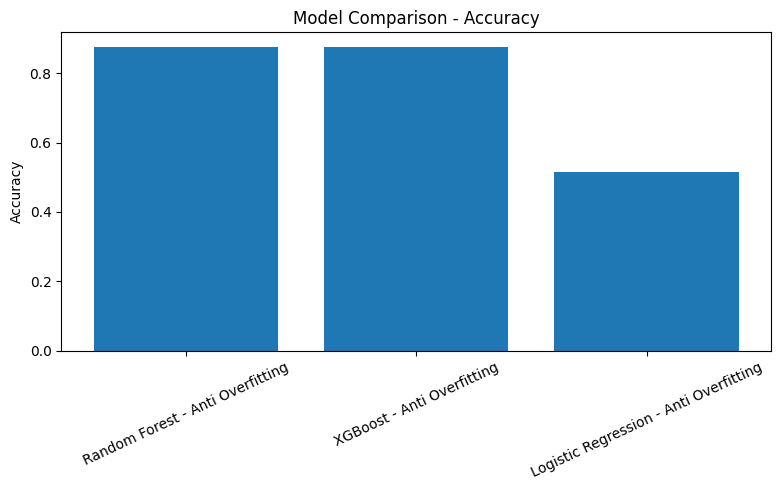

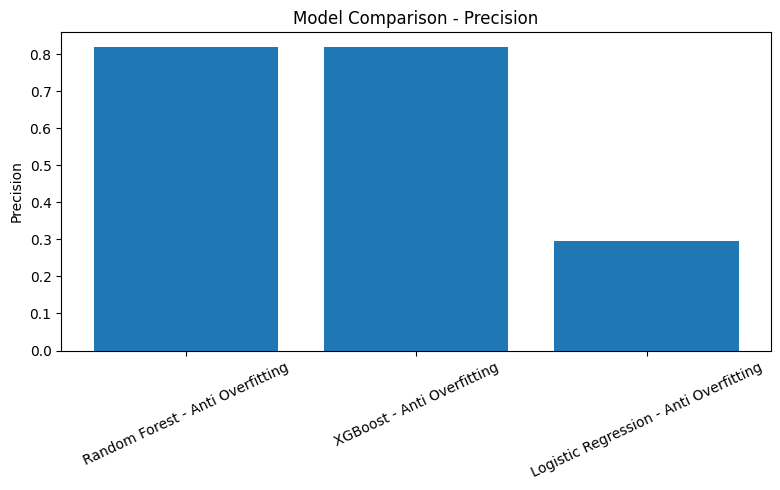

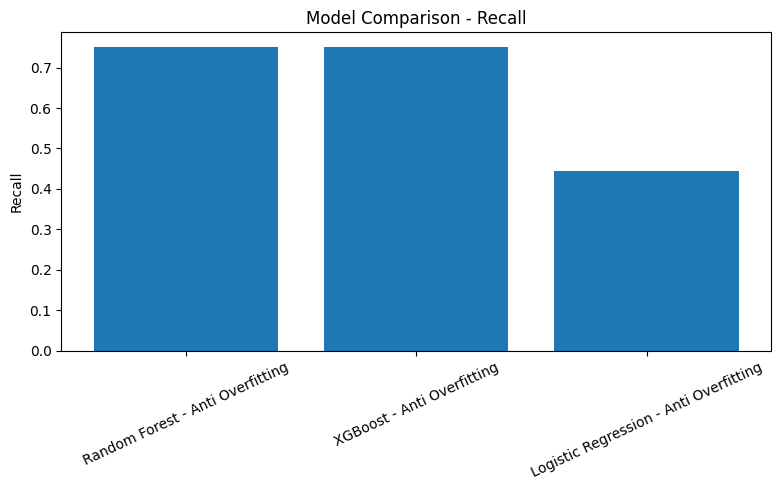

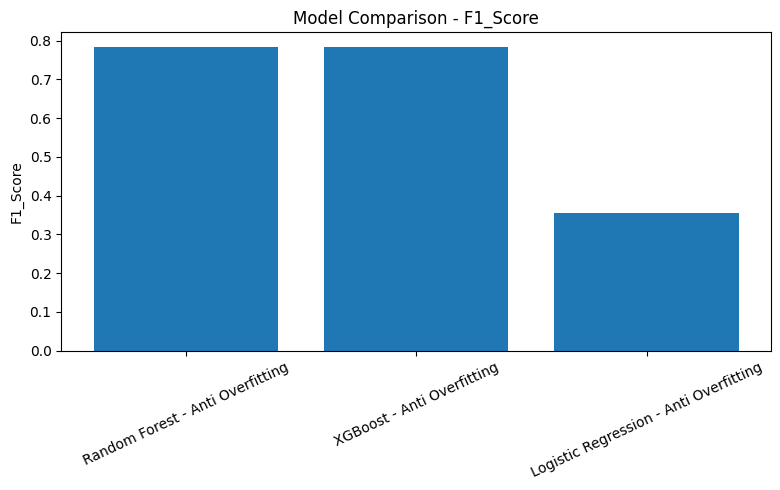

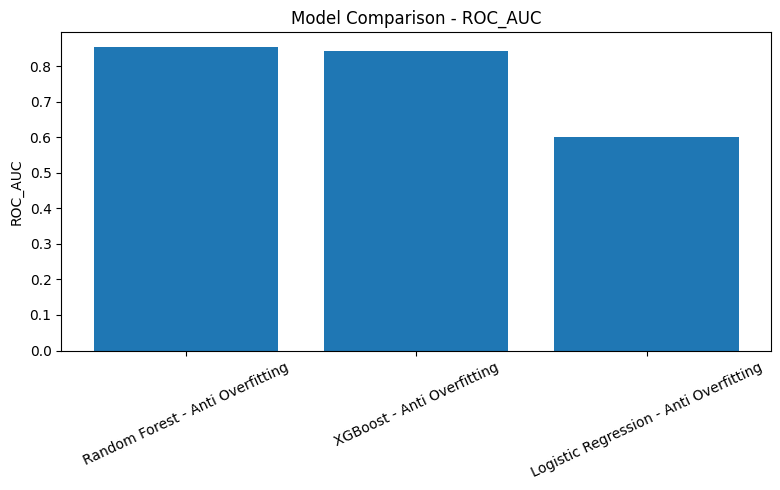

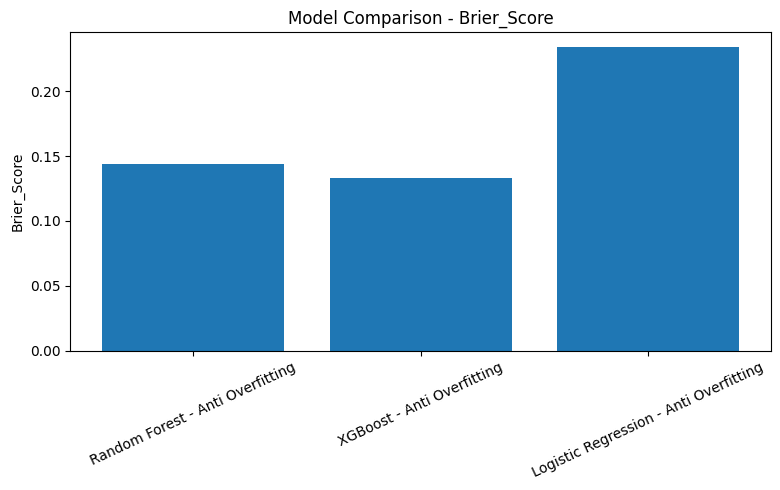

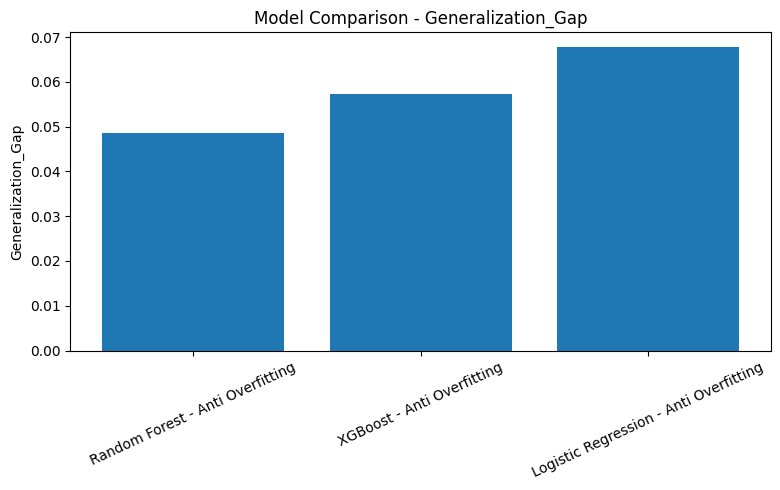

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON - ANTI-OVERFITTING MODELS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Load model metric files
# ------------------------------------------------------------

lr_metrics = pd.read_csv("LogisticRegression_AntiOverfitting_Metrics_Final.csv")
rf_metrics = pd.read_csv("RandomForest_AntiOverfitting_Metrics_Final.csv")
xgb_metrics = pd.read_csv("XGBoost_AntiOverfitting_Metrics_Final.csv")

# ------------------------------------------------------------
# STEP 2: Combine metrics
# ------------------------------------------------------------

comparison_df = pd.concat(
    [lr_metrics, rf_metrics, xgb_metrics],
    ignore_index=True
)

# ------------------------------------------------------------
# STEP 3: Load bias-variance / generalization gap files
# ------------------------------------------------------------

lr_bias = pd.read_csv("LogisticRegression_AntiOverfitting_BiasVariance_Final.csv")
rf_bias = pd.read_csv("RandomForest_AntiOverfitting_BiasVariance_Final.csv")
xgb_bias = pd.read_csv("XGBoost_AntiOverfitting_BiasVariance_Final.csv")

def get_gap(bias_df):
    train_auc = bias_df.loc[bias_df["Dataset"] == "Training", "ROC_AUC"].values[0]
    test_auc = bias_df.loc[bias_df["Dataset"] == "Testing", "ROC_AUC"].values[0]
    return train_auc - test_auc

comparison_df["Generalization_Gap"] = [
    get_gap(lr_bias),
    get_gap(rf_bias),
    get_gap(xgb_bias)
]

# ------------------------------------------------------------
# STEP 4: Round values
# ------------------------------------------------------------

metric_cols = [
    "CV_ROC_AUC_Mean",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC",
    "Brier_Score",
    "Generalization_Gap"
]

comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

# ------------------------------------------------------------
# STEP 5: Sort models
# Primary: ROC-AUC higher is better
# Secondary: Generalization gap lower is better
# ------------------------------------------------------------

comparison_df = comparison_df.sort_values(
    by=["ROC_AUC", "Generalization_Gap"],
    ascending=[False, True]
)

print("FINAL MODEL COMPARISON")
display(comparison_df)

comparison_df.to_csv(
    "Final_Model_Comparison_AntiOverfitting.csv",
    index=False
)

# ------------------------------------------------------------
# STEP 6: Identify best model
# ------------------------------------------------------------

best_model = comparison_df.iloc[0]

print("\nBEST MODEL")
print("Model:", best_model["Model"])
print("Test ROC-AUC:", best_model["ROC_AUC"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1_Score"])
print("Brier Score:", best_model["Brier_Score"])
print("Generalization Gap:", best_model["Generalization_Gap"])

# ------------------------------------------------------------
# STEP 7: Plot model comparison
# ------------------------------------------------------------

plot_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC",
    "Brier_Score",
    "Generalization_Gap"
]

for metric in plot_metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["Model"], comparison_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# STEP 8: Automatic interpretation
# ============================================================

print("\nINTERPRETATION")

for _, row in comparison_df.iterrows():
    gap = row["Generalization_Gap"]

    if gap < 0.05:
        gap_comment = "minimal overfitting"
    elif gap < 0.10:
        gap_comment = "slight but acceptable overfitting"
    else:
        gap_comment = "possible overfitting"

    print(
        f"{row['Model']} achieved ROC-AUC of {row['ROC_AUC']} "
        f"with a generalization gap of {gap}, indicating {gap_comment}."
    )

print(
    f"\nBased on the highest ROC-AUC and lowest acceptable generalization gap, "
    f"the recommended final model is {best_model['Model']}."
)


INTERPRETATION
Random Forest - Anti Overfitting achieved ROC-AUC of 0.8532 with a generalization gap of 0.0486, indicating minimal overfitting.
XGBoost - Anti Overfitting achieved ROC-AUC of 0.8439 with a generalization gap of 0.0574, indicating slight but acceptable overfitting.
Logistic Regression - Anti Overfitting achieved ROC-AUC of 0.6025 with a generalization gap of 0.0677, indicating slight but acceptable overfitting.

Based on the highest ROC-AUC and lowest acceptable generalization gap, the recommended final model is Random Forest - Anti Overfitting.


**SAVE FINAL BEST MODEL**

In [ ]:
# ============================================================
# SAVE FINAL BEST MODEL FOR DEPLOYMENT
# Flask / FastAPI / Dash / Streamlit
# ============================================================

import os
import joblib
import pandas as pd

# ------------------------------------------------------------
# STEP 1: Create folders
# ------------------------------------------------------------

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# ------------------------------------------------------------
# STEP 2: Load final model comparison table
# ------------------------------------------------------------

comparison_df = pd.read_csv("Final_Model_Comparison_AntiOverfitting.csv")

comparison_df = comparison_df.sort_values(
    by=["ROC_AUC", "Generalization_Gap"],
    ascending=[False, True]
)

best_model_name = comparison_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

# ------------------------------------------------------------
# STEP 3: Select the trained best model object
# Make sure these objects already exist in your notebook:
# best_logreg_model
# best_rf_model
# best_xgb_model
# ------------------------------------------------------------

if "Logistic" in best_model_name:
    final_model = best_logreg_model
    model_filename = "models/final_best_model_logistic_regression.pkl"

elif "Random Forest" in best_model_name:
    final_model = best_rf_model
    model_filename = "models/final_best_model_random_forest.pkl"

elif "XGBoost" in best_model_name:
    final_model = best_xgb_model
    model_filename = "models/final_best_model_xgboost.pkl"

else:
    raise ValueError("Best model name not recognized.")

# ------------------------------------------------------------
# STEP 4: Save final best model
# ------------------------------------------------------------

joblib.dump(final_model, model_filename)

print("Final best model saved as:", model_filename)

# ------------------------------------------------------------
# STEP 5: Save selected features
# ------------------------------------------------------------

joblib.dump(
    selected_features,
    "models/selected_features.pkl"
)

pd.DataFrame({
    "Selected_Features": selected_features
}).to_csv(
    "outputs/selected_features.csv",
    index=False
)

# ------------------------------------------------------------
# STEP 6: Save model metadata
# ------------------------------------------------------------

metadata = {
    "best_model_name": best_model_name,
    "model_file": model_filename,
    "target": "TARGET_NEXT_QTR",
    "target_definition": "Bottom 25% DSPR = High Risk",
    "positive_class": "1 = High Risk",
    "negative_class": "0 = Low Risk",
    "feature_period": "2026 Q1",
    "prediction_period": "2026 Q2",
    "model_purpose": "Predict next-quarter debt servicing risk"
}

joblib.dump(
    metadata,
    "models/model_metadata.pkl"
)

pd.DataFrame([metadata]).to_csv(
    "outputs/model_metadata.csv",
    index=False
)

# ------------------------------------------------------------
# STEP 7: Save performance summary
# ------------------------------------------------------------

comparison_df.to_csv(
    "outputs/final_model_comparison.csv",
    index=False
)

print("Metadata and comparison files saved successfully.")

Best Model: Random Forest - Anti Overfitting
Final best model saved as: models/final_best_model_random_forest.pkl
Metadata and comparison files saved successfully.


**Predict on New Data**

In [ ]:
# ============================================================
# LOAD FINAL MODEL FOR DEPLOYMENT
# ============================================================

import joblib
import pandas as pd

metadata = joblib.load("models/model_metadata.pkl")

model = joblib.load(metadata["model_file"])

selected_features = joblib.load("models/selected_features.pkl")

print("Loaded model:", metadata["best_model_name"])

In [ ]:
# new_data must contain the same selected feature columns

X_new = new_data[selected_features]

prob_high_risk = model.predict_proba(X_new)[:, 1]

prediction = model.predict(X_new)

result_df = new_data.copy()

result_df["Probability_High_Risk"] = prob_high_risk
result_df["Prediction"] = prediction
result_df["Risk_Level"] = result_df["Prediction"].map({
    0: "Low Risk",
    1: "High Risk"
})

result_df.head()